In [242]:
import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1024**3:.1f} GB")

Available RAM: 1.0 GB


In [244]:

# ============================================================
# CELL 1: Imports & Configuration
# ============================================================

import sqlite3
import pandas as pd
import numpy as np
import warnings
import time
import math
from datetime import datetime

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('future.no_silent_downcasting', True)

DB_PATH = r'C:\Users\Sarthak\Documents\ML\fighter-beta\mma_fighters.db'
print("✔ Imports complete")

✔ Imports complete


In [245]:

# ============================================================
# CELL 2: Database Connection
# ============================================================

conn = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f"✔ Connected. Tables: {len(tables)}")

fights_count = pd.read_sql("SELECT COUNT(*) as c FROM fights_v2", conn)['c'].iloc[0]
print(f"✔ Total fights in DB: {fights_count}")


✔ Connected. Tables: 10
✔ Total fights in DB: 11127


In [246]:


# ============================================================
# CELL 3: Helper Functions
# ============================================================

def parse_reach(r):
    if pd.isna(r) or r == '--': return None
    try: return float(r.replace('"', ''))
    except: return None

def parse_height(h):
    if pd.isna(h) or h == '--': return None
    try:
        parts = h.replace('"', '').split("'")
        return int(parts[0]) * 12 + int(parts[1])
    except: return None

def parse_age(dob, fight_date):
    if pd.isna(dob) or pd.isna(fight_date): return None
    try:
        birth = datetime.strptime(dob, "%b %d, %Y")
        fight = datetime.strptime(fight_date, "%Y-%m-%d")
        return (fight - birth).days / 365.25
    except: return None

def parse_fight_duration(ending_round, ending_time):
    try:
        mins, secs = ending_time.split(':')
        final_round_minutes = int(mins) + int(secs) / 60
        return ((ending_round - 1) * 5) + final_round_minutes
    except: return 15.0

# Time decay: 1.5 year half-life (λ ≈ 0.00127)
LAM = math.log(2) / (1.5 * 365)

def time_decay_weights(dates, as_of_date, lam=LAM):
    as_of = datetime.strptime(as_of_date, "%Y-%m-%d")
    weights = []
    for d in dates:
        fight_dt = datetime.strptime(d, "%Y-%m-%d")
        days_ago = (as_of - fight_dt).days
        w = np.exp(-lam * max(days_ago, 0))
        weights.append(w)
    weights = np.array(weights)
    return weights / weights.sum() if weights.sum() > 0 else weights

def kish_effective_n(weights):
    """Kish effective sample size — more honest than raw count with decayed weights"""
    if weights.sum() == 0: return 0
    return (weights.sum() ** 2) / (weights ** 2).sum()
    
def normalize_weight_class(wc):
    if pd.isna(wc): return None
    wc = wc.strip()
    
    # Drop women's divisions
    if "Women's" in wc: return None
    
    # Map to base weight classes
    base_classes = [
        'Heavyweight', 'Light Heavyweight', 'Middleweight',
        'Welterweight', 'Lightweight', 'Featherweight',
        'Bantamweight', 'Flyweight', 'Catch Weight'
    ]
    for base in base_classes:
        if base in wc:
            return f'{base} Bout'
    
    return None

print(f"✔ Lambda (1.5yr half-life): {LAM:.6f}")
print("✔ Helper functions ready")

✔ Lambda (1.5yr half-life): 0.001266
✔ Helper functions ready


In [375]:
# ============================================================
# CELL 4: Pre-Cache Fight Data (with Poisson-Gamma & Beta-Binomial smoothing)
# ============================================================

print("Fetching all fight stats (no date filter)...")
start = time.time()

# ── Raw stats ──────────────────────────────────────────────
all_fight_stats_raw = pd.read_sql("""
    SELECT 
        f.fight_id,
        f.event_date,
        f.weight_class,
        f.ending_round,
        f.ending_time,
        f.method,
        ff.fighter_id,
        SUM(frs.sig_str_landed)    as sig_str_landed,
        SUM(frs.sig_str_attempted) as sig_str_attempted,
        SUM(frs.td_landed)         as td_landed,
        SUM(frs.td_attempted)      as td_attempted,
        SUM(frs.sub_attempts)      as sub_attempts,
        SUM(frs.ctrl_seconds)      as ctrl_seconds,
        SUM(frs.knockdowns)        as knockdowns
    FROM fight_round_stats_v2 frs
    JOIN fight_rounds_v2 fr      ON SUBSTR(frs.round_id, 1, INSTR(frs.round_id, ':') - 1) = fr.fight_id
    JOIN fights_v2 f             ON fr.fight_id   = f.fight_id
    JOIN fight_fighters_v2 ff    ON f.fight_id    = ff.fight_id 
                                AND frs.fighter_id = ff.fighter_id
    GROUP BY f.fight_id, ff.fighter_id
""", conn)

# Actual fight duration
all_fight_stats_raw['actual_minutes'] = all_fight_stats_raw.apply(
    lambda r: parse_fight_duration(r['ending_round'], r['ending_time']), axis=1
)
all_fight_stats_raw = all_fight_stats_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

# ── Step 1: Compute weight-class rate priors ─────────────────
print("Computing weight-class priors...")

all_fight_stats_raw['wc_norm'] = all_fight_stats_raw['weight_class'].apply(normalize_weight_class)
valid = all_fight_stats_raw[all_fight_stats_raw['wc_norm'].notna()].copy()

pg_stats = {
    'sig_str_landed': 0.7,
    'td_landed':      7.0,
    'sub_attempts':   12.0,
    'knockdowns':     20.0,
    'ctrl_seconds':   2.0,
}

wc_rates     = {}
global_rates = {}

for stat, tau in pg_stats.items():
    global_total       = valid[stat].sum()
    global_mins        = valid['actual_minutes'].sum()
    global_rates[stat] = global_total / global_mins if global_mins > 0 else 0

    for wc, grp in valid.groupby('wc_norm'):
        if wc not in wc_rates:
            wc_rates[wc] = {}
        total = grp[stat].sum()
        mins  = grp['actual_minutes'].sum()
        wc_rates[wc][stat] = total / mins if mins > 0 else global_rates[stat]

bb_stats = {
    'str_acc': {'num': 'sig_str_landed', 'den': 'sig_str_attempted', 'tau': 0.7},
    'td_acc':  {'num': 'td_landed',      'den': 'td_attempted',      'tau': 7.0},
}

wc_bb_priors     = {}
global_bb_priors = {}

for stat, cfg in bb_stats.items():
    global_num = valid[cfg['num']].sum()
    global_den = valid[cfg['den']].sum()
    global_bb_priors[stat] = global_num / global_den if global_den > 0 else 0.5

    for wc, grp in valid.groupby('wc_norm'):
        if wc not in wc_bb_priors:
            wc_bb_priors[wc] = {}
        num = grp[cfg['num']].sum()
        den = grp[cfg['den']].sum()
        wc_bb_priors[wc][stat] = num / den if den > 0 else global_bb_priors[stat]

print(f"✓ Weight class priors computed for {len(wc_rates)} classes")

# ── Step 2: Apply smoothing ────────────────────────────────
print("Applying Poisson-Gamma and Beta-Binomial smoothing...")

all_fight_stats = all_fight_stats_raw.copy()

def get_wc_rate(wc, stat):
    wc_norm = normalize_weight_class(wc) if wc else None
    if wc_norm and wc_norm in wc_rates and stat in wc_rates[wc_norm]:
        return wc_rates[wc_norm][stat]
    return global_rates.get(stat, 0)

def get_wc_bb(wc, stat):
    wc_norm = normalize_weight_class(wc) if wc else None
    if wc_norm and wc_norm in wc_bb_priors and stat in wc_bb_priors[wc_norm]:
        return wc_bb_priors[wc_norm][stat]
    return global_bb_priors.get(stat, 0.5)

for stat, tau in pg_stats.items():
    smoothed = []
    for _, row in all_fight_stats.iterrows():
        t         = max(row['actual_minutes'], 0.1)
        wc_rate   = get_wc_rate(row['weight_class'], stat)
        x         = row[stat]
        post_rate = (wc_rate * tau + x) / (tau + t)
        smoothed.append(t * post_rate)
    all_fight_stats[f'{stat}_smooth'] = smoothed

for stat, cfg in bb_stats.items():
    smoothed = []
    for _, row in all_fight_stats.iterrows():
        wc_rate = get_wc_bb(row['weight_class'], stat)
        tau     = cfg['tau']
        x       = row[cfg['num']]
        n       = row[cfg['den']]
        if n == 0:
            smoothed.append(wc_rate)
        else:
            smoothed.append((wc_rate * tau + x) / (tau + n))
    all_fight_stats[f'{stat}_smooth'] = smoothed

# ── Step 3: Compute per-minute rates from smoothed values ──
t = all_fight_stats['actual_minutes'].clip(lower=0.1)

all_fight_stats['slpm']              = all_fight_stats['sig_str_landed_smooth'] / t
all_fight_stats['str_acc']           = all_fight_stats['str_acc_smooth']
all_fight_stats['td_acc']            = all_fight_stats['td_acc_smooth']
all_fight_stats['td_avg']            = all_fight_stats['td_landed_smooth']    / (t / 15)
all_fight_stats['sub_avg']           = all_fight_stats['sub_attempts_smooth'] / (t / 15)
all_fight_stats['ctrl_time_per_min'] = all_fight_stats['ctrl_seconds_smooth'] / 60 / t
all_fight_stats['kd_per_min']        = all_fight_stats['knockdowns_smooth']   / t

all_fight_stats = all_fight_stats.replace([np.inf, -np.inf], np.nan).fillna(0)
all_fight_stats = all_fight_stats.sort_values('event_date').reset_index(drop=True)

# ── Step 4: Rebuild dicts ──────────────────────────────────
fighter_fights_dict = {
    fid: grp.sort_values('event_date').reset_index(drop=True)
    for fid, grp in all_fight_stats.groupby('fighter_id')
}

all_opponents = pd.read_sql("""
    SELECT ff1.fight_id, ff1.fighter_id, ff2.fighter_id as opponent_id
    FROM fight_fighters_v2 ff1
    JOIN fight_fighters_v2 ff2 
        ON ff1.fight_id = ff2.fight_id 
       AND ff1.fighter_id != ff2.fighter_id
""", conn)

opponents_dict = {
    (row['fight_id'], row['fighter_id']): row['opponent_id']
    for _, row in all_opponents.iterrows()
}

print(f"Done in {time.time()-start:.1f}s")
print(f"✓ Fighters cached: {len(fighter_fights_dict)}")
print(f"✓ Fight records:   {len(all_fight_stats)}")
print(f"✓ Opponent lookups:{len(opponents_dict)}")
print(f"✓ Smoothing: Poisson-Gamma for counts, Beta-Binomial for accuracies")

Fetching all fight stats (no date filter)...
Computing weight-class priors...
✓ Weight class priors computed for 8 classes
Applying Poisson-Gamma and Beta-Binomial smoothing...
Done in 11.3s
✓ Fighters cached: 3760
✓ Fight records:   21568
✓ Opponent lookups:22254
✓ Smoothing: Poisson-Gamma for counts, Beta-Binomial for accuracies


In [353]:
# ============================================================
# CELL 4b-ii: Per-Fight Grappling Dominance + Control Share
# ============================================================
# Run AFTER Cell 4b (strike_breakdown) and Cell 4 (all_fight_stats).
#
# Adds to all_fight_stats:
#   - ctrl_share: ctrl_seconds / total_fight_seconds (BB smoothed)
#   - grappling_dominance: composite of TD success, ctrl share, sub pressure
#     relative to opponent in that fight
#
# Adds to strike_breakdown (via merge):
#   - ctrl_share (for downstream dec_avg + adjperf in Cell 6b)

print("Computing control share + grappling dominance per fight...")
start = time.time()

# Ensure weight_class_norm exists
if 'weight_class_norm' not in all_fight_stats.columns:
    all_fight_stats['weight_class_norm'] = all_fight_stats['weight_class'].apply(normalize_weight_class)

# ── Step 1: Control Share (Beta-Binomial smoothed) ───────────
# Author: "Model control time as a proportion, not per-minute rate"
# ctrl_seconds / (fight_duration_seconds) → bounded [0, 1]

# Weight-class priors for control share
ctrl_share_global = (
    all_fight_stats['ctrl_seconds'].sum() /
    (all_fight_stats['actual_minutes'].sum() * 60)
)

ctrl_share_wc_priors = {}
for wc, grp in all_fight_stats[all_fight_stats['weight_class_norm'].notna()].groupby('weight_class_norm'):
    total_ctrl = grp['ctrl_seconds'].sum()
    total_secs = (grp['actual_minutes'] * 60).sum()
    ctrl_share_wc_priors[wc] = total_ctrl / total_secs if total_secs > 0 else ctrl_share_global

TAU_CTRL_SHARE = 2.0  # BB tau — low because ctrl has high variance

def get_ctrl_share_prior(wc):
    wc_n = normalize_weight_class(wc) if wc else None
    if wc_n and wc_n in ctrl_share_wc_priors:
        return ctrl_share_wc_priors[wc_n]
    return ctrl_share_global

# Apply BB smoothing per fight
ctrl_share_smoothed = []
for _, row in all_fight_stats.iterrows():
    fight_secs = max(row['actual_minutes'] * 60, 1)
    ctrl_secs  = row['ctrl_seconds']
    prior      = get_ctrl_share_prior(row['weight_class'])
    
    # BB: (prior * tau + successes) / (tau + trials)
    smoothed = (prior * TAU_CTRL_SHARE + ctrl_secs) / (TAU_CTRL_SHARE + fight_secs)
    ctrl_share_smoothed.append(float(smoothed))

all_fight_stats['ctrl_share'] = ctrl_share_smoothed

# ── Step 2: Grappling Dominance (per-fight composite) ────────
# Combines: TD success in fight + ctrl share + sub pressure
# All relative to opponent in that fight
# This directly captures the "grappling underdog" signal

grappling_rows = []
for fight_id in all_fight_stats['fight_id'].unique():
    fight_data = all_fight_stats[all_fight_stats['fight_id'] == fight_id]
    if len(fight_data) != 2:
        continue
    
    for _, row in fight_data.iterrows():
        fid = row['fighter_id']
        opp_id = opponents_dict.get((fight_id, fid))
        if not opp_id:
            continue
        
        opp_data = fight_data[fight_data['fighter_id'] == opp_id]
        if len(opp_data) == 0:
            continue
        opp = opp_data.iloc[0]
        
        # TD share: own_td_landed / (own + opp td_landed)
        total_td = row['td_landed'] + opp['td_landed']
        td_share = row['td_landed'] / total_td if total_td > 0 else 0.5
        
        # Ctrl share differential
        ctrl_diff = row['ctrl_share'] - opp['ctrl_share']
        
        # Sub pressure: own sub_attempts / fight_minutes (already have sub_avg)
        # Relative to opponent
        total_sub = row['sub_attempts'] + opp['sub_attempts']
        sub_share = row['sub_attempts'] / total_sub if total_sub > 0 else 0.5
        
        # Composite: weighted combination
        # TD share is most important (gets you to the ground)
        # Ctrl share shows what you do once there
        # Sub share shows finishing threat
        grappling_dom = (0.4 * td_share) + (0.4 * ctrl_diff + 0.5) + (0.2 * sub_share)
        # Shifted so 0.5 = neutral, >0.5 = grappling dominant
        
        grappling_rows.append({
            'fight_id': fight_id,
            'fighter_id': fid,
            'ctrl_share': row['ctrl_share'],
            'td_share': float(td_share),
            'sub_share': float(sub_share),
            'grappling_dominance': float(grappling_dom),
        })

grappling_df = pd.DataFrame(grappling_rows)

# Merge into all_fight_stats
all_fight_stats = all_fight_stats.merge(
    grappling_df[['fight_id', 'fighter_id', 'td_share', 'sub_share', 'grappling_dominance']],
    on=['fight_id', 'fighter_id'], how='left'
)
all_fight_stats[['td_share', 'sub_share', 'grappling_dominance']] = (
    all_fight_stats[['td_share', 'sub_share', 'grappling_dominance']].fillna(0.5)
)

# Also merge ctrl_share + grappling features into strike_breakdown
# so Cell 6b can give them dec_avg + adjperf treatment
strike_breakdown = strike_breakdown.merge(
    grappling_df[['fight_id', 'fighter_id', 'ctrl_share', 'td_share',
                   'sub_share', 'grappling_dominance']],
    on=['fight_id', 'fighter_id'], how='left'
)
strike_breakdown[['ctrl_share', 'td_share', 'sub_share', 'grappling_dominance']] = (
    strike_breakdown[['ctrl_share', 'td_share', 'sub_share', 'grappling_dominance']].fillna(0.5)
)

# Rebuild dicts
fighter_fights_dict = {
    fid: grp.sort_values('event_date').reset_index(drop=True)
    for fid, grp in all_fight_stats.groupby('fighter_id')
}
strike_breakdown_dict = {
    fid: grp.sort_values('event_date').reset_index(drop=True)
    for fid, grp in strike_breakdown.groupby('fighter_id')
}

print(f"Done in {time.time()-start:.1f}s")
print(f"✓ ctrl_share (BB tau={TAU_CTRL_SHARE}): "
      f"mean={all_fight_stats['ctrl_share'].mean():.3f}, "
      f"median={all_fight_stats['ctrl_share'].median():.3f}")
print(f"✓ td_share:             mean={all_fight_stats['td_share'].mean():.3f}")
print(f"✓ sub_share:            mean={all_fight_stats['sub_share'].mean():.3f}")
print(f"✓ grappling_dominance:  mean={all_fight_stats['grappling_dominance'].mean():.3f}")
print(f"✓ Added to all_fight_stats + strike_breakdown + rebuilt dicts")

Computing control share + grappling dominance per fight...
Done in 39.9s
✓ ctrl_share (BB tau=2.0): mean=0.423, median=0.155
✓ td_share:             mean=0.500
✓ sub_share:            mean=0.500
✓ grappling_dominance:  mean=0.800
✓ Added to all_fight_stats + strike_breakdown + rebuilt dicts


In [376]:
# ============================================================
# CELL 4c: Pre-Cache Strike Defense (what opponents land on each fighter)
# ============================================================

print("Building strike defense lookup...")
start = time.time()

# For each fight, get opponent's strike breakdown against this fighter
strike_defense = strike_breakdown.copy()

# Map opponent's stats to the fighter they were landed on
opp_strike_rows = []
for _, row in strike_defense.iterrows():
    opp_id = opponents_dict.get((row['fight_id'], row['fighter_id']))
    if opp_id:
        opp_strike_rows.append({
            'fight_id':         row['fight_id'],
            'event_date':       row['event_date'],
            'fighter_id':       opp_id,          # the fighter who RECEIVED these strikes
            'head_allowed':     row['head_lpm'],
            'body_allowed':     row['body_lpm'],
            'leg_allowed':      row['leg_lpm'],
            'distance_allowed': row['distance_lpm'],
            'clinch_allowed':   row['clinch_lpm'],
            'ground_allowed':   row['ground_lpm'],
        })

strike_defense_df = pd.DataFrame(opp_strike_rows).sort_values('event_date').reset_index(drop=True)

# Dict keyed by fighter_id
strike_defense_dict = {
    fid: grp.sort_values('event_date').reset_index(drop=True)
    for fid, grp in strike_defense_df.groupby('fighter_id')
}

print(f"Done in {time.time()-start:.1f}s")
print(f"✔ Defense records: {len(strike_defense_df)}")
print(f"✔ Fighters with defense data: {len(strike_defense_dict)}")

Building strike defense lookup...
Done in 2.7s
✔ Defense records: 21568
✔ Fighters with defense data: 3761


In [377]:
# ============================================================
# CELL 4d: Pre-Cache Fighter Results
# ============================================================

print("Building fighter results cache...")

results_raw = pd.read_sql("""
    SELECT 
        ff.fighter_id,
        ff.fight_id,
        ff.result,
        f.method
    FROM fight_fighters_v2 ff
    JOIN fights_v2 f ON ff.fight_id = f.fight_id
""", conn)

# Map (fighter_id, fight_id) → result
# Tag KO wins separately for ko_rate
fighter_results_dict = {}
for _, row in results_raw.iterrows():
    result = row['result']
    if result == 'win' and row['method'] == 'KO/TKO':
        tagged = 'ko_win'
    else:
        tagged = result
    fighter_results_dict[(row['fighter_id'], row['fight_id'])] = tagged

print(f"✔ Results cached: {len(fighter_results_dict)}")

Building fighter results cache...
✔ Results cached: 22254


In [378]:
# ============================================================
# CELL 4e: Pre-Cache Round 1 Stats (with R1 Strike Breakdown)
# ============================================================
# NEW: Also fetches R1 head/body/leg/clinch from
# fight_round_sig_strikes_v2 and joins into r1_stats.
# These give R1-specific strike targeting features.

print("Fetching Round 1 stats...")
start = time.time()

r1_stats = pd.read_sql("""
    SELECT
        f.fight_id,
        f.event_date,
        f.weight_class,
        f.ending_round,
        f.ending_time,
        ff.fighter_id,
        frs.sig_str_landed    as r1_sig_str_landed,
        frs.sig_str_attempted as r1_sig_str_attempted,
        frs.ctrl_seconds      as r1_ctrl_seconds,
        frs.td_landed         as r1_td_landed,
        frs.td_attempted      as r1_td_attempted,
        frs.knockdowns        as r1_knockdowns,
        frs.reversals         as r1_reversals,
        frs.sub_attempts      as r1_sub_attempts
    FROM fight_round_stats_v2 frs
    JOIN fights_v2 f          ON SUBSTR(frs.round_id, 1, INSTR(frs.round_id, ':') - 1) = f.fight_id
    JOIN fight_fighters_v2 ff ON f.fight_id    = ff.fight_id
                             AND frs.fighter_id = ff.fighter_id
    WHERE CAST(SUBSTR(frs.round_id, INSTR(frs.round_id, ':') + 1) AS INTEGER) = 1
""", conn)

# ── NEW: Fetch R1 sig strike breakdown (head/body/leg/clinch) ──
r1_sig_strikes = pd.read_sql("""
    SELECT
        f.fight_id,
        ss.fighter_id,
        ss.head_landed    as r1_head_landed,
        ss.head_attempted as r1_head_attempted,
        ss.body_landed    as r1_body_landed,
        ss.body_attempted as r1_body_attempted,
        ss.leg_landed     as r1_leg_landed,
        ss.leg_attempted  as r1_leg_attempted,
        ss.clinch_landed  as r1_clinch_landed,
        ss.clinch_attempted as r1_clinch_attempted,
        ss.distance_landed  as r1_distance_landed,
        ss.ground_landed    as r1_ground_landed
    FROM fight_round_sig_strikes_v2 ss
    JOIN fight_rounds_v2 fr ON ss.round_id = fr.round_id
    JOIN fights_v2 f        ON fr.fight_id = f.fight_id
    WHERE CAST(SUBSTR(ss.round_id, INSTR(ss.round_id, ':') + 1) AS INTEGER) = 1
""", conn)

# Join R1 sig strikes into r1_stats
r1_stats = r1_stats.merge(
    r1_sig_strikes, on=['fight_id', 'fighter_id'], how='left'
)
r1_sig_cols = [c for c in r1_sig_strikes.columns if c.startswith('r1_')]
r1_stats[r1_sig_cols] = r1_stats[r1_sig_cols].fillna(0)

# R1 exposure capped at 5 minutes
r1_stats['r1_minutes'] = r1_stats.apply(
    lambda r: min(parse_fight_duration(r['ending_round'], r['ending_time']), 5.0), axis=1
)
r1_stats['wc_norm'] = r1_stats['weight_class'].apply(normalize_weight_class)

r1_stats = r1_stats.replace([np.inf, -np.inf], np.nan).fillna(0)

# ── R1 Poisson-Gamma tau values (from author's blog) ──────
r1_pg_stats = {
    'r1_sig_str_landed': 0.7,
    'r1_td_landed':      9.0,
    'r1_sub_attempts':   15.0,
    'r1_knockdowns':     12.0,
    'r1_reversals':      60.0,
    # NEW: R1 strike breakdown counts
    'r1_head_landed':    1.0,
    'r1_body_landed':    3.0,
    'r1_leg_landed':     2.0,
    'r1_clinch_landed':  5.0,
}

# ── R1 weight-class rate priors ───────────────────────────
r1_valid = r1_stats[r1_stats['wc_norm'].notna()].copy()

r1_wc_rates     = {}
r1_global_rates = {}

for stat, tau in r1_pg_stats.items():
    total = r1_valid[stat].sum()
    mins  = r1_valid['r1_minutes'].sum()
    r1_global_rates[stat] = total / mins if mins > 0 else 0

    for wc, grp in r1_valid.groupby('wc_norm'):
        if wc not in r1_wc_rates:
            r1_wc_rates[wc] = {}
        wc_total = grp[stat].sum()
        wc_mins  = grp['r1_minutes'].sum()
        r1_wc_rates[wc][stat] = wc_total / wc_mins if wc_mins > 0 else r1_global_rates[stat]

# ── R1 Beta-Binomial for td_acc and ctrl ──────────────────
r1_bb_stats = {
    'r1_td_acc':  {'num': 'r1_td_landed', 'den': 'r1_td_attempted', 'tau': 9.0},
    'r1_ctrl':    {'num': 'r1_ctrl_seconds', 'den': 'r1_minutes', 'tau': 1.0},
}

r1_wc_bb     = {}
r1_global_bb = {}

for stat, cfg in r1_bb_stats.items():
    num_total = r1_valid[cfg['num']].sum()
    den_total = r1_valid[cfg['den']].sum()
    if stat == 'r1_ctrl':
        den_total = (r1_valid['r1_minutes'] * 60).sum()
    r1_global_bb[stat] = num_total / den_total if den_total > 0 else 0.5

    for wc, grp in r1_valid.groupby('wc_norm'):
        if wc not in r1_wc_bb:
            r1_wc_bb[wc] = {}
        num = grp[cfg['num']].sum()
        den = grp[cfg['den']].sum()
        if stat == 'r1_ctrl':
            den = (grp['r1_minutes'] * 60).sum()
        r1_wc_bb[wc][stat] = num / den if den > 0 else r1_global_bb[stat]

# ── Apply Poisson-Gamma smoothing to R1 counts ───────────
def get_r1_wc_rate(wc, stat):
    wc_n = normalize_weight_class(wc) if wc else None
    if wc_n and wc_n in r1_wc_rates and stat in r1_wc_rates[wc_n]:
        return r1_wc_rates[wc_n][stat]
    return r1_global_rates.get(stat, 0)

def get_r1_wc_bb(wc, stat):
    wc_n = normalize_weight_class(wc) if wc else None
    if wc_n and wc_n in r1_wc_bb and stat in r1_wc_bb[wc_n]:
        return r1_wc_bb[wc_n][stat]
    return r1_global_bb.get(stat, 0.5)

for stat, tau in r1_pg_stats.items():
    smoothed = []
    for _, row in r1_stats.iterrows():
        t       = max(row['r1_minutes'], 0.1)
        wc_rate = get_r1_wc_rate(row['weight_class'], stat)
        x       = row[stat]
        post    = (wc_rate * tau + x) / (tau + t)
        smoothed.append(t * post)
    r1_stats[f'{stat}_smooth'] = smoothed

# ── Apply Beta-Binomial to R1 td_acc and ctrl ────────────
for stat, cfg in r1_bb_stats.items():
    smoothed = []
    for _, row in r1_stats.iterrows():
        wc_rate = get_r1_wc_bb(row['weight_class'], stat)
        tau     = cfg['tau']
        x       = row[cfg['num']]
        if stat == 'r1_ctrl':
            n = row['r1_minutes'] * 60
        else:
            n = row[cfg['den']]
        if n == 0:
            smoothed.append(wc_rate)
        else:
            smoothed.append((wc_rate * tau + x) / (tau + n))
    r1_stats[f'{stat}_smooth'] = smoothed

# ── Compute per-minute rates from smoothed values ────────
t = r1_stats['r1_minutes'].clip(lower=0.1)

r1_stats['r1_slpm']           = r1_stats['r1_sig_str_landed_smooth'] / t
r1_stats['r1_td_per_min']     = r1_stats['r1_td_landed_smooth'] / t
r1_stats['r1_td_acc']         = r1_stats['r1_td_acc_smooth']
r1_stats['r1_ctrl_per_min']   = r1_stats['r1_ctrl_smooth']  # already a share
r1_stats['r1_kd_per_min']     = r1_stats['r1_knockdowns_smooth'] / t
r1_stats['r1_rev_per_min']    = r1_stats['r1_reversals_smooth'] / t
r1_stats['r1_sub_per_min']    = r1_stats['r1_sub_attempts_smooth'] / t
r1_stats['r1_td_att_per_min'] = r1_stats['r1_td_attempted'] / t

# NEW: R1 strike breakdown per-minute rates (smoothed)
r1_stats['r1_head_lpm']       = r1_stats['r1_head_landed_smooth'] / t
r1_stats['r1_body_lpm']       = r1_stats['r1_body_landed_smooth'] / t
r1_stats['r1_leg_lpm']        = r1_stats['r1_leg_landed_smooth'] / t
r1_stats['r1_clinch_lpm']     = r1_stats['r1_clinch_landed_smooth'] / t

r1_stats = r1_stats.replace([np.inf, -np.inf], np.nan).fillna(0)
r1_stats = r1_stats.sort_values('event_date').reset_index(drop=True)

r1_stats_dict = {
    fid: grp.sort_values('event_date').reset_index(drop=True)
    for fid, grp in r1_stats.groupby('fighter_id')
}

print(f"Done in {time.time()-start:.1f}s")
print(f"✔ R1 records: {len(r1_stats)}")
print(f"✔ Fighters with R1 data: {len(r1_stats_dict)}")
print(f"✔ R1 Poisson-Gamma smoothed: {list(r1_pg_stats.keys())}")
print(f"✔ R1 Beta-Binomial smoothed: {list(r1_bb_stats.keys())}")
print(f"✔ NEW R1 strike rates: r1_head_lpm, r1_body_lpm, r1_leg_lpm, r1_clinch_lpm")

Fetching Round 1 stats...
Done in 14.3s
✔ R1 records: 21568
✔ Fighters with R1 data: 3760
✔ R1 Poisson-Gamma smoothed: ['r1_sig_str_landed', 'r1_td_landed', 'r1_sub_attempts', 'r1_knockdowns', 'r1_reversals', 'r1_head_landed', 'r1_body_landed', 'r1_leg_landed', 'r1_clinch_landed']
✔ R1 Beta-Binomial smoothed: ['r1_td_acc', 'r1_ctrl']
✔ NEW R1 strike rates: r1_head_lpm, r1_body_lpm, r1_leg_lpm, r1_clinch_lpm


In [379]:
# ============================================================
# CELL 4f: Weight Class Priors
# ============================================================

print("Building weight class priors...")

STATS_FOR_PRIORS = ['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg',
                    'ctrl_time_per_min', 'kd_per_min']

# Add normalized weight class to all_fight_stats
all_fight_stats['weight_class_norm'] = all_fight_stats['weight_class'].apply(normalize_weight_class)

# Filter to valid weight classes only
valid_stats = all_fight_stats[all_fight_stats['weight_class_norm'].notna()].copy()

# Compute per-weight-class median and MAD for each stat
wc_priors = {}
global_priors = {}

for stat in STATS_FOR_PRIORS:
    # Global prior as fallback
    global_median = float(np.median(valid_stats[stat].values))
    global_mad    = float(np.median(np.abs(valid_stats[stat].values - global_median)))
    global_priors[stat] = {'mean': global_median, 'mad': max(global_mad, 0.01)}

    # Per weight class
    for wc, grp in valid_stats.groupby('weight_class_norm'):
        if wc not in wc_priors:
            wc_priors[wc] = {}
        vals   = grp[stat].values
        median = float(np.median(vals))
        mad    = float(np.median(np.abs(vals - median)))
        wc_priors[wc][stat] = {'mean': median, 'mad': max(mad, 0.01)}

print(f"✔ Weight classes with priors: {len(wc_priors)}")
print(f"✔ Global fallback priors: {len(global_priors)} stats")
print("\nWeight classes:")
for wc in sorted(wc_priors.keys()):
    print(f"  {wc}")

Building weight class priors...
✔ Weight classes with priors: 8
✔ Global fallback priors: 7 stats

Weight classes:
  Bantamweight Bout
  Catch Weight Bout
  Featherweight Bout
  Flyweight Bout
  Heavyweight Bout
  Lightweight Bout
  Middleweight Bout
  Welterweight Bout


In [380]:
# ============================================================
# CELL 4g: Pre-Cache Per-Fight AdjPerf Z-Scores
# ============================================================
# NEW: After computing each fight's AdjPerf snapshot, store it
# so we can decay-average historical z-scores in Cell 6.
#
# WARNING: This cell is slow (~10-15 min) since it computes
# AdjPerf for every fighter across every fight historically.
# Run once and reuse fighter_adjperf_history dict.
#
# This resolves the key finding from the author's videos:
#   His naming: sig_str_land_ratio_dec_adjperf_dec_avg_diff
#   Means:      AdjPerf z-scores are ALSO decayed averaged
#               across recent fights, not just used as snapshots.
#
# Pipeline comparison:
#   Yours (before): dec_avg → AdjPerf snapshot → diff
#   His (confirmed): dec_avg → AdjPerf snapshot → decay avg → diff

STATS = ['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg',
         'ctrl_time_per_min', 'kd_per_min']

print("Pre-caching per-fight AdjPerf z-scores...")
start = time.time()

# Dict to store: {fighter_id: DataFrame with columns
#   [fight_id, event_date, {stat}_adjperf_snapshot]}
fighter_adjperf_history = {}

# We need to compute AdjPerf for every fight in all_fight_stats
# using only prior fight history — strict no-leakage
all_fights_sorted = all_fight_stats.sort_values('event_date').reset_index(drop=True)

pop_means = {s: float(np.median(all_fight_stats[s].values)) for s in STATS}
pop_mads  = {s: float(np.median(np.abs(
    all_fight_stats[s].values - pop_means[s]
))) for s in STATS}

adjperf_rows = []

for _, fight_row in all_fights_sorted.iterrows():
    fid   = fight_row['fighter_id']
    fdate = fight_row['event_date']
    fid_fight = fight_row['fight_id']

    # Get opponent
    opp_id = opponents_dict.get((fid_fight, fid))
    if not opp_id or opp_id not in fighter_fights_dict:
        continue

    fighter_hist = fighter_fights_dict[fid]
    opp_hist     = fighter_fights_dict[opp_id]

    fighter_prev = fighter_hist[fighter_hist['event_date'] < fdate].tail(WINDOW)
    opp_prev     = opp_hist[opp_hist['event_date'] < fdate]

    if len(fighter_prev) == 0:
        continue

    row = {'fighter_id': fid, 'fight_id': fid_fight, 'event_date': fdate}

    f_weights = time_decay_weights(fighter_prev['event_date'].tolist(), fdate)
    f_n_eff   = kish_effective_n(f_weights)

    for stat in STATS:
        # Layer 1: Fighter decayed avg
        dec_avg  = np.average(fighter_prev[stat].values, weights=f_weights)
        smoothed = bayesian_smooth(dec_avg, f_n_eff, pop_means[stat], K_MEAN)

        # Layer 2/3: Opponent allowed baseline → AdjPerf snapshot
        opp_allowed, opp_dates = [], []
        for _, opp_fight in opp_prev.iterrows():
            opp_opp_id = opponents_dict.get((opp_fight['fight_id'], opp_id))
            if opp_opp_id and opp_opp_id in fighter_fights_dict:
                opp_opp_hist  = fighter_fights_dict[opp_opp_id]
                opp_opp_this  = opp_opp_hist[
                    opp_opp_hist['fight_id'] == opp_fight['fight_id']
                ]
                if len(opp_opp_this) > 0:
                    opp_allowed.append(opp_opp_this[stat].iloc[0])
                    opp_dates.append(opp_fight['event_date'])

        if len(opp_allowed) >= 2:
            opp_w     = time_decay_weights(opp_dates, fdate)
            opp_n_eff = kish_effective_n(opp_w)
            opp_mu    = bayesian_smooth(
                np.average(opp_allowed, weights=opp_w),
                opp_n_eff, pop_means[stat], K_MEAN
            )
            opp_sigma = max(bayesian_smooth(
                np.average(np.abs(np.array(opp_allowed) -
                    np.average(opp_allowed, weights=opp_w)), weights=opp_w),
                opp_n_eff, pop_mads[stat], K_MAD
            ), 0.01)
            snapshot = float(np.clip((smoothed - opp_mu) / opp_sigma, -7, 7))
        else:
            snapshot = 0.0

        row[f'{stat}_adjperf_snapshot'] = snapshot

    adjperf_rows.append(row)

adjperf_history_df = pd.DataFrame(adjperf_rows).sort_values('event_date').reset_index(drop=True)

# Build per-fighter dict for O(1) lookups
fighter_adjperf_history = {
    fid: grp.sort_values('event_date').reset_index(drop=True)
    for fid, grp in adjperf_history_df.groupby('fighter_id')
}

print(f"Done in {time.time()-start:.1f}s")
print(f"✓ AdjPerf history cached for {len(fighter_adjperf_history)} fighters")
print(f"✓ Total records: {len(adjperf_history_df)}")

Pre-caching per-fight AdjPerf z-scores...
Done in 309.8s
✓ AdjPerf history cached for 2661 fighters
✓ Total records: 17755


In [381]:

# ============================================================
# CELL 5: Generate Base Fights (2016–2026, clean methods only)
# ============================================================

EXCLUDED_METHODS = ['S-DEC', 'M-DEC', 'Overturned', 'CNC', 'DQ', 'Other', 'Decision']
MIN_PREV_FIGHTS  = 3   # both fighters need this many prior UFC fights

def generate_base_fights_filtered(start_date='2014-01-01', end_date='2026-12-31'):
    excl = "', '".join(EXCLUDED_METHODS)
    fights = pd.read_sql(f"""
        SELECT 
            f.fight_id,
            f.event_date,
            f.event_name,
            f.weight_class,
            f.method,
            f.ending_round,
            f.ending_time,
            ff1.fighter_id  as fighter_1_id,
            fv1.name        as fighter_1_name,
            ff2.fighter_id  as fighter_2_id,
            fv2.name        as fighter_2_name,
            CASE WHEN ff1.result = 'win' THEN 1 ELSE 0 END as winner
        FROM fights_v2 f
        JOIN fight_fighters_v2 ff1 ON f.fight_id = ff1.fight_id AND ff1.corner = 'fighter_1'
        JOIN fight_fighters_v2 ff2 ON f.fight_id = ff2.fight_id AND ff2.corner = 'fighter_2'
        JOIN fighters_v2 fv1       ON ff1.fighter_id = fv1.fighter_id
        JOIN fighters_v2 fv2       ON ff2.fighter_id = fv2.fighter_id
        WHERE f.event_date >= '{start_date}'
          AND f.event_date <= '{end_date}'
          AND f.method NOT IN ('{excl}')
        ORDER BY f.event_date
    """, conn)

    valid = []
    for _, fight in fights.iterrows():
        f1_id, f2_id, fdate = fight['fighter_1_id'], fight['fighter_2_id'], fight['event_date']

        f1_prev = len(fighter_fights_dict[f1_id][fighter_fights_dict[f1_id]['event_date'] < fdate]) \
                  if f1_id in fighter_fights_dict else 0
        f2_prev = len(fighter_fights_dict[f2_id][fighter_fights_dict[f2_id]['event_date'] < fdate]) \
                  if f2_id in fighter_fights_dict else 0

        if f1_prev >= MIN_PREV_FIGHTS and f2_prev >= MIN_PREV_FIGHTS:
            valid.append(fight)

    filtered = pd.DataFrame(valid)
    print(f"Raw fights  (2016-{end_date[:4]}): {len(fights)}")
    print(f"After {MIN_PREV_FIGHTS}+ fight filter: {len(filtered)}")
    print(f"Dropped: {len(fights)-len(filtered)} ({(len(fights)-len(filtered))/len(fights)*100:.1f}%)")
    return filtered


base_fights = generate_base_fights_filtered()
print(f"\n✔ Base fights shape: {base_fights.shape}")
print(f"✔ Date range: {base_fights['event_date'].min()} to {base_fights['event_date'].max()}")
print(f"✔ Winner distribution: {base_fights['winner'].value_counts().to_dict()}")

Raw fights  (2016-2026): 5721
After 3+ fight filter: 2837
Dropped: 2884 (50.4%)

✔ Base fights shape: (2837, 12)
✔ Date range: 2014-01-15 to 2026-02-07
✔ Winner distribution: {0: 1450, 1: 1387}


In [382]:
# ============================================================
# CELL 6: Three-Layer Feature Function
#          Changes: K_MAD=4.0, median-based MAD
# ============================================================

STATS  = ['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg',
          'ctrl_time_per_min', 'kd_per_min']
K_MEAN = 4.0
K_MAD  = 4.0   # Changed from 6.0 to match author
WINDOW = 5

def bayesian_smooth(observed, n_eff, population_mean, k):
    w = n_eff / (n_eff + k)
    return w * observed + (1 - w) * population_mean

def calculate_three_layer_features_v2(fighter_id, opponent_id, as_of_date,
                                       stats=STATS, window=WINDOW):
    if fighter_id not in fighter_fights_dict or opponent_id not in fighter_fights_dict:
        return None

    fighter_hist  = fighter_fights_dict[fighter_id]
    opponent_hist = fighter_fights_dict[opponent_id]

    fighter_prev  = fighter_hist[fighter_hist['event_date']   < as_of_date]
    opponent_prev = opponent_hist[opponent_hist['event_date'] < as_of_date]

    if len(fighter_prev) == 0 or len(opponent_prev) == 0:
        return None

    pop_means = {s: float(np.median(all_fight_stats[s].values)) for s in stats}
    pop_mads  = {s: float(np.median(np.abs(
        all_fight_stats[s].values - pop_means[s]
    ))) for s in stats}

    fighter_recent  = fighter_prev.tail(window)
    fighter_weights = time_decay_weights(fighter_recent['event_date'].tolist(), as_of_date)
    fighter_n_eff   = kish_effective_n(fighter_weights)

    features = {}

    for stat in stats:
        # --- Layer 1: Fighter's time-decayed average ---
        decayed_avg   = np.average(fighter_recent[stat].values, weights=fighter_weights)
        smoothed_stat = bayesian_smooth(decayed_avg, fighter_n_eff, pop_means[stat], K_MEAN)
        features[f'{stat}_dec_avg'] = smoothed_stat

        # --- Layer 2: Opponent's allowed baseline ---
        opp_allowed, opp_dates = [], []
        for _, opp_fight in opponent_prev.iterrows():
            opp_opp_id = opponents_dict.get((opp_fight['fight_id'], opponent_id))
            if opp_opp_id and opp_opp_id in fighter_fights_dict:
                opp_opp_fights     = fighter_fights_dict[opp_opp_id]
                opp_opp_this_fight = opp_opp_fights[
                    opp_opp_fights['fight_id'] == opp_fight['fight_id']
                ]
                if len(opp_opp_this_fight) > 0:
                    opp_allowed.append(opp_opp_this_fight[stat].iloc[0])
                    opp_dates.append(opp_fight['event_date'])

        if len(opp_allowed) >= 2:
            opp_weights = time_decay_weights(opp_dates, as_of_date)
            opp_n_eff   = kish_effective_n(opp_weights)
            opp_mean    = np.average(opp_allowed, weights=opp_weights)

            # CHANGED: Median-based MAD instead of weighted mean of abs devs
            opp_mad     = float(np.median(np.abs(np.array(opp_allowed) - np.median(opp_allowed))))

            opp_mu    = bayesian_smooth(opp_mean, opp_n_eff, pop_means[stat], K_MEAN)
            opp_sigma = max(
                bayesian_smooth(opp_mad, opp_n_eff, pop_mads[stat], K_MAD),
                0.01
            )
            features[f'{stat}_opp_dec_avg'] = opp_mu
            features[f'{stat}_opp_mad']     = opp_sigma
            features[f'{stat}_adjperf']     = np.clip(
                (smoothed_stat - opp_mu) / opp_sigma, -7, 7
            )
        else:
            features[f'{stat}_opp_dec_avg'] = pop_means[stat]
            features[f'{stat}_opp_mad']     = 1.0
            features[f'{stat}_adjperf']     = 0.0

        # --- dec_adjperf — decay average of historical z-scores ---
        if fighter_id in fighter_adjperf_history:
            ap_hist  = fighter_adjperf_history[fighter_id]
            ap_prev  = ap_hist[ap_hist['event_date'] < as_of_date].tail(window)
            snap_col = f'{stat}_adjperf_snapshot'

            if len(ap_prev) > 0 and snap_col in ap_prev.columns:
                ap_weights = time_decay_weights(
                    ap_prev['event_date'].tolist(), as_of_date
                )
                ap_n_eff   = kish_effective_n(ap_weights)
                ap_dec_avg = np.average(ap_prev[snap_col].values, weights=ap_weights)
                features[f'{stat}_dec_adjperf'] = bayesian_smooth(
                    ap_dec_avg, ap_n_eff, 0.0, K_MEAN
                )
            else:
                features[f'{stat}_dec_adjperf'] = 0.0
        else:
            features[f'{stat}_dec_adjperf'] = 0.0

    return features


print("✓ Three-layer feature function ready")
print(f"  STATS: {STATS}")
print(f"  K_MEAN={K_MEAN}, K_MAD={K_MAD} (was 6.0), WINDOW={WINDOW}")
print(f"  MAD method: median-based (was weighted mean)")

✓ Three-layer feature function ready
  STATS: ['slpm', 'str_acc', 'td_acc', 'td_avg', 'sub_avg', 'ctrl_time_per_min', 'kd_per_min']
  K_MEAN=4.0, K_MAD=4.0 (was 6.0), WINDOW=5
  MAD method: median-based (was weighted mean)


In [383]:
# ============================================================
# CELL 6b: Strike Breakdown Feature Function (Refactored)
# ============================================================
# NEW: Added exchange_ratio, targeting_share, strike_share
# to STRIKE_STATS_OFF — each gets dec_avg + adjperf treatment.

STRIKE_STATS_OFF = ['head_lpm', 'body_lpm', 'leg_lpm',
                    'distance_lpm', 'clinch_lpm', 'ground_lpm',
                    'head_acc', 'body_acc', 'distance_acc',
                    # Derived ratio features
                    'exchange_ratio', 'targeting_share', 'strike_share',
                    # Grappling dominance features
                    'ctrl_share', 'td_share', 'sub_share',
                    'grappling_dominance']

STRIKE_STATS_DEF = ['head_allowed', 'body_allowed', 'leg_allowed',
                    'distance_allowed', 'clinch_allowed', 'ground_allowed']

STRIKE_ADJPERF_OFF = STRIKE_STATS_OFF
STRIKE_ADJPERF_DEF = STRIKE_STATS_DEF


def calculate_strike_features(fighter_id, opponent_id, as_of_date, window=WINDOW):
    features = {}

    # Precompute population priors
    off_priors = {}
    for s in STRIKE_STATS_OFF:
        if s in strike_breakdown.columns:
            median = float(strike_breakdown[s].median())
            mad    = float(max(np.median(np.abs(
                strike_breakdown[s].values - median
            )), 0.01))
            off_priors[s] = {'mean': median, 'mad': mad}
        else:
            off_priors[s] = {'mean': 0.0, 'mad': 1.0}

    def_priors = {
        s: {
            'mean': float(strike_defense_df[s].median()),
            'mad':  float(max(np.median(np.abs(
                strike_defense_df[s].values - strike_defense_df[s].median()
            )), 0.01))
        } for s in STRIKE_STATS_DEF
    }

    # --- Fighter's own offensive decayed averages ---
    fighter_off_smoothed = {}
    if fighter_id in strike_breakdown_dict:
        hist = strike_breakdown_dict[fighter_id]
        prev = hist[hist['event_date'] < as_of_date].tail(window)
        if len(prev) > 0:
            weights = time_decay_weights(prev['event_date'].tolist(), as_of_date)
            n_eff   = kish_effective_n(weights)
            for s in STRIKE_STATS_OFF:
                if s not in prev.columns:
                    features[f'{s}_dec_avg'] = off_priors[s]['mean']
                    fighter_off_smoothed[s]  = off_priors[s]['mean']
                    continue
                dec_avg  = np.average(prev[s].values, weights=weights)
                smoothed = bayesian_smooth(dec_avg, n_eff, off_priors[s]['mean'], K_MEAN)
                features[f'{s}_dec_avg'] = smoothed
                fighter_off_smoothed[s]  = smoothed
        else:
            for s in STRIKE_STATS_OFF:
                features[f'{s}_dec_avg'] = off_priors[s]['mean']
                fighter_off_smoothed[s]  = off_priors[s]['mean']
    else:
        for s in STRIKE_STATS_OFF:
            features[f'{s}_dec_avg'] = off_priors[s]['mean']
            fighter_off_smoothed[s]  = off_priors[s]['mean']

    # --- Fighter's own defensive decayed averages ---
    fighter_def_smoothed = {}
    if fighter_id in strike_defense_dict:
        hist = strike_defense_dict[fighter_id]
        prev = hist[hist['event_date'] < as_of_date].tail(window)
        if len(prev) > 0:
            weights = time_decay_weights(prev['event_date'].tolist(), as_of_date)
            n_eff   = kish_effective_n(weights)
            for s in STRIKE_STATS_DEF:
                dec_avg  = np.average(prev[s].values, weights=weights)
                smoothed = bayesian_smooth(dec_avg, n_eff, def_priors[s]['mean'], K_MEAN)
                features[f'{s}_dec_avg'] = smoothed
                fighter_def_smoothed[s]  = smoothed
        else:
            for s in STRIKE_STATS_DEF:
                features[f'{s}_dec_avg'] = 0.0
                fighter_def_smoothed[s]  = 0.0
    else:
        for s in STRIKE_STATS_DEF:
            features[f'{s}_dec_avg'] = 0.0
            fighter_def_smoothed[s]  = 0.0

    # --- AdjPerf for all offensive stats ---
    if opponent_id in strike_breakdown_dict:
        opp_hist = strike_breakdown_dict[opponent_id]
        opp_prev = opp_hist[opp_hist['event_date'] < as_of_date]

        for s in STRIKE_ADJPERF_OFF:
            observed = fighter_off_smoothed[s]
            pop_mean = off_priors[s]['mean']
            pop_mad  = off_priors[s]['mad']

            opp_allowed, opp_dates = [], []
            for _, opp_fight in opp_prev.iterrows():
                opp_opp_id = opponents_dict.get((opp_fight['fight_id'], opponent_id))
                if opp_opp_id and opp_opp_id in strike_breakdown_dict:
                    opp_opp_hist = strike_breakdown_dict[opp_opp_id]
                    opp_opp_this = opp_opp_hist[
                        opp_opp_hist['fight_id'] == opp_fight['fight_id']
                    ]
                    if len(opp_opp_this) > 0 and s in opp_opp_this.columns:
                        opp_allowed.append(opp_opp_this[s].iloc[0])
                        opp_dates.append(opp_fight['event_date'])

            if len(opp_allowed) >= 2:
                opp_w     = time_decay_weights(opp_dates, as_of_date)
                opp_n_eff = kish_effective_n(opp_w)
                opp_mean  = np.average(opp_allowed, weights=opp_w)
                opp_mad   = float(np.median(np.abs(
                    np.array(opp_allowed) - np.median(opp_allowed)
                )))
                mu        = bayesian_smooth(opp_mean, opp_n_eff, pop_mean, K_MEAN)
                sigma     = max(bayesian_smooth(opp_mad, opp_n_eff, pop_mad, K_MAD), 0.01)
                features[f'{s}_adjperf'] = np.clip((observed - mu) / sigma, -7, 7)
            else:
                features[f'{s}_adjperf'] = 0.0
    else:
        for s in STRIKE_ADJPERF_OFF:
            features[f'{s}_adjperf'] = 0.0

    # --- AdjPerf for all defensive stats ---
    if opponent_id in strike_breakdown_dict:
        opp_hist = strike_breakdown_dict[opponent_id]
        opp_prev = opp_hist[opp_hist['event_date'] < as_of_date]

        for s in STRIKE_ADJPERF_DEF:
            observed = fighter_def_smoothed[s]
            pop_mean = def_priors[s]['mean']
            pop_mad  = def_priors[s]['mad']

            opp_allowed, opp_dates = [], []
            for _, opp_fight in opp_prev.iterrows():
                opp_opp_id = opponents_dict.get((opp_fight['fight_id'], opponent_id))
                if opp_opp_id and opp_opp_id in strike_defense_dict:
                    opp_opp_hist = strike_defense_dict[opp_opp_id]
                    opp_opp_this = opp_opp_hist[
                        opp_opp_hist['fight_id'] == opp_fight['fight_id']
                    ]
                    if len(opp_opp_this) > 0:
                        opp_allowed.append(opp_opp_this[s].iloc[0])
                        opp_dates.append(opp_fight['event_date'])

            if len(opp_allowed) >= 2:
                opp_w     = time_decay_weights(opp_dates, as_of_date)
                opp_n_eff = kish_effective_n(opp_w)
                opp_mean  = np.average(opp_allowed, weights=opp_w)
                opp_mad   = float(np.median(np.abs(
                    np.array(opp_allowed) - np.median(opp_allowed)
                )))
                mu        = bayesian_smooth(opp_mean, opp_n_eff, pop_mean, K_MEAN)
                sigma     = max(bayesian_smooth(opp_mad, opp_n_eff, pop_mad, K_MAD), 0.01)
                features[f'{s}_adjperf'] = np.clip((observed - mu) / sigma, -7, 7)
            else:
                features[f'{s}_adjperf'] = 0.0
    else:
        for s in STRIKE_ADJPERF_DEF:
            features[f'{s}_adjperf'] = 0.0

    return features


print("✓ Strike feature function ready (with derived ratios + grappling)")
print(f"  Offensive: {len(STRIKE_STATS_OFF)} stats × 2 (dec_avg + adjperf)")
print(f"  Includes: exchange_ratio, targeting_share, strike_share")
print(f"  Includes: ctrl_share, td_share, sub_share, grappling_dominance")
print(f"  Defensive: {len(STRIKE_STATS_DEF)} stats × 2 (dec_avg + adjperf)")
print(f"  NOTE: AdjPerf uses median-based MAD (consistent with Cell 6)")

✓ Strike feature function ready (with derived ratios + grappling)
  Offensive: 16 stats × 2 (dec_avg + adjperf)
  Includes: exchange_ratio, targeting_share, strike_share
  Includes: ctrl_share, td_share, sub_share, grappling_dominance
  Defensive: 6 stats × 2 (dec_avg + adjperf)
  NOTE: AdjPerf uses median-based MAD (consistent with Cell 6)


In [387]:
# ============================================================
# CELL 6c: Rolling Career Stats (Refactored)
# ============================================================
# NEW: Added decision_rate (BB tau=20) and sub_landing_rate (BB tau=9)
# Both are Beta-Binomial smoothed with weight-class priors.

# ── Pre-compute weight-class priors for career stats ──────
career_wc_priors = {}
career_global_priors = {}

# Build from fighter_results_dict + all_fight_stats
all_results_list = []
for (fid, fight_id), result in fighter_results_dict.items():
    # Look up method for decision rate
    method = None
    fight_rows = all_fight_stats[all_fight_stats['fight_id'] == fight_id]
    if len(fight_rows) > 0:
        method = fight_rows.iloc[0].get('method', None)

    all_results_list.append({
        'fighter_id': fid,
        'fight_id': fight_id,
        'is_win': 1 if result in ('win', 'ko_win') else 0,
        'is_ko':  1 if result == 'ko_win' else 0,
        'is_decision': 1 if method and 'DEC' in str(method).upper() else 0,
    })
results_df = pd.DataFrame(all_results_list)

# Merge weight class
results_with_wc = results_df.merge(
    all_fight_stats[['fight_id', 'fighter_id', 'weight_class']].drop_duplicates(),
    on=['fight_id', 'fighter_id'], how='left'
)
results_with_wc['wc_norm'] = results_with_wc['weight_class'].apply(normalize_weight_class)

# Global priors
career_global_priors['win'] = results_with_wc['is_win'].mean()
career_global_priors['ko']  = results_with_wc['is_ko'].mean()
career_global_priors['dec'] = results_with_wc['is_decision'].mean()

# Per weight class
for wc, grp in results_with_wc[results_with_wc['wc_norm'].notna()].groupby('wc_norm'):
    career_wc_priors[wc] = {
        'win': grp['is_win'].mean(),
        'ko':  grp['is_ko'].mean(),
        'dec': grp['is_decision'].mean(),
    }

# ── Pre-cache decision results per fight for O(1) lookups ──
# Map (fighter_id, fight_id) → is_decision
fight_decision_dict = {}
for _, row in results_with_wc.iterrows():
    fight_decision_dict[(row['fighter_id'], row['fight_id'])] = row['is_decision']

# Tau values from author
TAU_WIN = 25.0
TAU_KO  = 23.0
TAU_DEC = 20.0  # NEW
TAU_SUB_LAND = 9.0  # NEW

print(f"✔ Career priors computed")
print(f"  Global win rate:      {career_global_priors['win']:.3f}")
print(f"  Global KO rate:       {career_global_priors['ko']:.3f}")
print(f"  Global decision rate: {career_global_priors['dec']:.3f}")


def get_career_wc_prior(wc, stat):
    wc_n = normalize_weight_class(wc) if wc else None
    if wc_n and wc_n in career_wc_priors and stat in career_wc_priors[wc_n]:
        return career_wc_priors[wc_n][stat]
    return career_global_priors.get(stat, 0.5)


def calculate_career_stats(fighter_id, opponent_id, fight_id, as_of_date, window=10):
    features = {}

    defaults = {
        'days_since_last_fight': 180,
        'win_ratio':             0.5,
        'win_adjperf':           0.0,
        'ko_rate':               0.0,
        'ko_opp_dec_avg':        0.0,
        'decision_rate':         0.5,
        'sub_landing_rate':      0.0,
        'td_defense':            0.5,
        'td_land_ratio_opp':     0.0,
        'ctrl_ratio_opp':        0.0,
        'sub_att_allowed_pm':    0.0,
        'kd_allowed_pm':         0.0,
    }

    if fighter_id not in fighter_fights_dict:
        return defaults

    hist = fighter_fights_dict[fighter_id]
    prev = hist[hist['event_date'] < as_of_date]

    if len(prev) == 0:
        return defaults

    # --- Days since last fight ---
    last_date = prev.iloc[-1]['event_date']
    features['days_since_last_fight'] = (
        datetime.strptime(as_of_date, "%Y-%m-%d") -
        datetime.strptime(last_date,  "%Y-%m-%d")
    ).days

    # --- Get fight weight class for priors ---
    fight_wc = None
    if fight_id in all_fight_stats['fight_id'].values:
        wc_row = all_fight_stats[all_fight_stats['fight_id'] == fight_id]
        if len(wc_row) > 0:
            fight_wc = wc_row.iloc[0]['weight_class']

    # --- Win ratio + KO rate + Decision rate (Beta-Binomial smoothed) ---
    prior_fids = prev['fight_id'].tolist()
    results    = [fighter_results_dict.get((fighter_id, fid)) for fid in prior_fids]
    results    = [r for r in results if r is not None]

    n_fights = len(results)
    if n_fights > 0:
        n_wins = sum(1 for r in results if r in ('win', 'ko_win'))
        n_kos  = sum(1 for r in results if r == 'ko_win')

        # Beta-Binomial smoothed win ratio
        win_prior = get_career_wc_prior(fight_wc, 'win')
        win_ratio = (win_prior * TAU_WIN + n_wins) / (TAU_WIN + n_fights)

        # Beta-Binomial smoothed KO rate
        ko_prior = get_career_wc_prior(fight_wc, 'ko')
        ko_rate  = (ko_prior * TAU_KO + n_kos) / (TAU_KO + n_fights)

        # NEW: Beta-Binomial smoothed decision rate
        n_decs   = sum(fight_decision_dict.get((fighter_id, fid), 0) for fid in prior_fids)
        dec_prior = get_career_wc_prior(fight_wc, 'dec')
        decision_rate = (dec_prior * TAU_DEC + n_decs) / (TAU_DEC + n_fights)

        features['win_ratio']     = win_ratio
        features['ko_rate']       = ko_rate
        features['decision_rate'] = decision_rate
    else:
        features['win_ratio']     = get_career_wc_prior(fight_wc, 'win')
        features['ko_rate']       = get_career_wc_prior(fight_wc, 'ko')
        features['decision_rate'] = get_career_wc_prior(fight_wc, 'dec')

    win_ratio = features['win_ratio']

    # --- NEW: Sub landing rate (Beta-Binomial smoothed) ---
    # sub_landed / sub_attempted across career
    total_sub_landed   = 0
    total_sub_attempted = 0
    for _, fight_row in prev.iterrows():
        result = fighter_results_dict.get((fighter_id, fight_row['fight_id']))
        sub_att = fight_row.get('sub_attempts', 0)
        total_sub_attempted += sub_att
        # A sub is "landed" if this fighter won by submission in this fight
        if result == 'win':
            method = None
            fight_rows = all_fight_stats[
                all_fight_stats['fight_id'] == fight_row['fight_id']
            ]
            if len(fight_rows) > 0:
                method = fight_rows.iloc[0].get('method', '')
            if method and 'SUB' in str(method).upper():
                total_sub_landed += 1

    # Use global sub success rate as prior (~5-10% of attempts)
    sub_land_prior = 0.05  # rough global prior
    if total_sub_attempted > 0:
        features['sub_landing_rate'] = (
            (sub_land_prior * TAU_SUB_LAND + total_sub_landed) /
            (TAU_SUB_LAND + total_sub_attempted)
        )
    else:
        features['sub_landing_rate'] = sub_land_prior

    # --- Win rate AdjPerf ---
    if opponent_id in fighter_fights_dict:
        opp_hist = fighter_fights_dict[opponent_id]
        opp_prev = opp_hist[opp_hist['event_date'] < as_of_date]

        opp_win_rates, opp_dates = [], []
        for _, opp_fight in opp_prev.iterrows():
            opp_opp_id = opponents_dict.get((opp_fight['fight_id'], opponent_id))
            if opp_opp_id:
                opp_opp_fids = fighter_fights_dict.get(opp_opp_id)
                if opp_opp_fids is not None:
                    opp_opp_prev = opp_opp_fids[
                        opp_opp_fids['event_date'] < opp_fight['event_date']
                    ]
                    opp_opp_results = [
                        fighter_results_dict.get((opp_opp_id, fid))
                        for fid in opp_opp_prev['fight_id'].tolist()
                    ]
                    opp_opp_results = [r for r in opp_opp_results if r is not None]
                    if len(opp_opp_results) > 0:
                        opp_n = len(opp_opp_results)
                        opp_wins = sum(1 for r in opp_opp_results if r in ('win', 'ko_win'))
                        opp_opp_wr = (get_career_wc_prior(fight_wc, 'win') * TAU_WIN + opp_wins) / (TAU_WIN + opp_n)
                        opp_win_rates.append(opp_opp_wr)
                        opp_dates.append(opp_fight['event_date'])

        if len(opp_win_rates) >= 2:
            opp_w     = time_decay_weights(opp_dates, as_of_date)
            opp_n_eff = kish_effective_n(opp_w)
            opp_mean  = np.average(opp_win_rates, weights=opp_w)
            opp_mad   = float(np.median(np.abs(np.array(opp_win_rates) - np.median(opp_win_rates))))
            pop_mean  = 0.5
            pop_mad   = 0.15
            mu        = bayesian_smooth(opp_mean, opp_n_eff, pop_mean, K_MEAN)
            sigma     = max(bayesian_smooth(opp_mad, opp_n_eff, pop_mad, K_MAD), 0.01)
            features['win_adjperf'] = np.clip((win_ratio - mu) / sigma, -7, 7)
        else:
            features['win_adjperf'] = 0.0
    else:
        features['win_adjperf'] = 0.0

    # --- Opponent stats (rolling window) ---
    recent = prev.tail(window)
    total_td_att, total_td_land   = 0, 0
    total_sub_att, total_minutes  = 0, 0
    total_kd, total_minutes_kd    = 0, 0
    total_ctrl, total_fight_mins  = 0, 0
    opp_ko_rates, opp_ko_dates    = [], []
    opp_td_ratios, opp_td_dates   = [], []

    for _, fight_row in recent.iterrows():
        opp_id = opponents_dict.get((fight_row['fight_id'], fighter_id))
        if opp_id and opp_id in fighter_fights_dict:
            opp_hist  = fighter_fights_dict[opp_id]
            opp_this  = opp_hist[opp_hist['fight_id'] == fight_row['fight_id']]
            if len(opp_this) > 0:
                opp_row = opp_this.iloc[0]

                total_td_att  += opp_row['td_attempted']
                total_td_land += opp_row['td_landed']
                total_sub_att += opp_row['sub_attempts']
                total_minutes += opp_row['actual_minutes']
                total_kd         += opp_row['kd_per_min'] * opp_row['actual_minutes']
                total_minutes_kd += opp_row['actual_minutes']
                total_ctrl       += opp_row['ctrl_time_per_min'] * opp_row['actual_minutes']
                total_fight_mins += opp_row['actual_minutes']

                # KO rate opponent — smoothed
                opp_prev_fights = opp_hist[opp_hist['event_date'] < fight_row['event_date']]
                opp_results = [
                    fighter_results_dict.get((opp_id, fid))
                    for fid in opp_prev_fights['fight_id'].tolist()
                ]
                opp_results = [r for r in opp_results if r is not None]
                if len(opp_results) > 0:
                    opp_n_ko = len(opp_results)
                    opp_kos  = sum(1 for r in opp_results if r == 'ko_win')
                    opp_ko_smoothed = (get_career_wc_prior(fight_wc, 'ko') * TAU_KO + opp_kos) / (TAU_KO + opp_n_ko)
                    opp_ko_rates.append(opp_ko_smoothed)
                    opp_ko_dates.append(fight_row['event_date'])

                if opp_row['td_attempted'] > 0:
                    opp_td_ratios.append(opp_row['td_landed'] / opp_row['td_attempted'])
                    opp_td_dates.append(fight_row['event_date'])

    features['td_defense'] = (
        1 - (total_td_land / total_td_att) if total_td_att > 0 else 0.5
    )
    features['sub_att_allowed_pm'] = (
        total_sub_att / total_minutes if total_minutes > 0 else 0.0
    )
    features['kd_allowed_pm'] = (
        total_kd / total_minutes_kd if total_minutes_kd > 0 else 0.0
    )
    features['ctrl_ratio_opp'] = (
        total_ctrl / total_fight_mins if total_fight_mins > 0 else 0.0
    )

    if len(opp_ko_rates) >= 2:
        opp_w = time_decay_weights(opp_ko_dates, as_of_date)
        features['ko_opp_dec_avg'] = float(np.average(opp_ko_rates, weights=opp_w))
    else:
        features['ko_opp_dec_avg'] = 0.0

    if len(opp_td_ratios) >= 2:
        opp_w = time_decay_weights(opp_td_dates, as_of_date)
        features['td_land_ratio_opp'] = float(np.average(opp_td_ratios, weights=opp_w))
    else:
        features['td_land_ratio_opp'] = 0.0

    return features


print("✔ Career stats function ready (with decision_rate + sub_landing_rate)")
print(f"  win_ratio: tau={TAU_WIN}, ko_rate: tau={TAU_KO}")
print(f"  NEW decision_rate: tau={TAU_DEC}")
print(f"  NEW sub_landing_rate: tau={TAU_SUB_LAND}")

✔ Career priors computed
  Global win rate:      0.491
  Global KO rate:       0.169
  Global decision rate: 0.426
✔ Career stats function ready (with decision_rate + sub_landing_rate)
  win_ratio: tau=25.0, ko_rate: tau=23.0
  NEW decision_rate: tau=20.0
  NEW sub_landing_rate: tau=9.0


In [388]:
# ============================================================
# CELL 6d: Round 1 Feature Function (Refactored)
# ============================================================
# NEW: Added r1_head_lpm, r1_body_lpm, r1_leg_lpm, r1_clinch_lpm
# Each gets dec_avg + adjperf + opp_dec_avg treatment.

R1_STATS = ['r1_slpm', 'r1_ctrl_per_min', 'r1_td_acc',
            'r1_kd_per_min', 'r1_rev_per_min', 'r1_td_att_per_min',
            # NEW: R1 strike breakdown
            'r1_head_lpm', 'r1_body_lpm', 'r1_leg_lpm', 'r1_clinch_lpm']

def calculate_r1_features(fighter_id, opponent_id, as_of_date, window=WINDOW):
    features = {}

    # Precompute population priors
    r1_priors = {}
    for s in R1_STATS:
        if s in r1_stats.columns:
            median = float(r1_stats[s].median())
            mad    = float(max(np.median(np.abs(r1_stats[s].values - median)), 0.01))
            r1_priors[s] = {'mean': median, 'mad': mad}
        else:
            r1_priors[s] = {'mean': 0.0, 'mad': 1.0}

    # Ensure r1_td_att_per_min exists
    if 'r1_td_att_per_min' not in r1_stats.columns:
        r1_stats['r1_td_att_per_min'] = r1_stats['r1_td_attempted'] / r1_stats['r1_minutes'].clip(lower=0.1)
        r1_stats['r1_td_att_per_min'] = r1_stats['r1_td_att_per_min'].replace(
            [np.inf, -np.inf], np.nan
        ).fillna(0)
        for fid in r1_stats_dict:
            r1_stats_dict[fid] = r1_stats[r1_stats['fighter_id'] == fid].sort_values(
                'event_date'
            ).reset_index(drop=True)
        median = float(r1_stats['r1_td_att_per_min'].median())
        mad    = float(max(np.median(np.abs(
            r1_stats['r1_td_att_per_min'].values - median
        )), 0.01))
        r1_priors['r1_td_att_per_min'] = {'mean': median, 'mad': mad}

    # --- Fighter's own R1 decayed averages ---
    fighter_smoothed = {}
    if fighter_id in r1_stats_dict:
        hist = r1_stats_dict[fighter_id]
        prev = hist[hist['event_date'] < as_of_date].tail(window)
        if len(prev) > 0:
            weights = time_decay_weights(prev['event_date'].tolist(), as_of_date)
            n_eff   = kish_effective_n(weights)
            for s in R1_STATS:
                if s not in prev.columns:
                    features[f'{s}_dec_avg'] = r1_priors[s]['mean']
                    fighter_smoothed[s]      = r1_priors[s]['mean']
                    continue
                dec_avg  = np.average(prev[s].values, weights=weights)
                smoothed = bayesian_smooth(dec_avg, n_eff, r1_priors[s]['mean'], K_MEAN)
                features[f'{s}_dec_avg'] = smoothed
                fighter_smoothed[s]      = smoothed
        else:
            for s in R1_STATS:
                features[f'{s}_dec_avg'] = r1_priors[s]['mean']
                fighter_smoothed[s]      = r1_priors[s]['mean']
    else:
        for s in R1_STATS:
            features[f'{s}_dec_avg'] = r1_priors[s]['mean']
            fighter_smoothed[s]      = r1_priors[s]['mean']

    # --- Full AdjPerf + opponent allowed for all R1 stats ---
    if opponent_id in r1_stats_dict:
        opp_hist = r1_stats_dict[opponent_id]
        opp_prev = opp_hist[opp_hist['event_date'] < as_of_date]

        for s in R1_STATS:
            observed = fighter_smoothed[s]
            pop_mean = r1_priors[s]['mean']
            pop_mad  = r1_priors[s]['mad']

            opp_allowed, opp_dates = [], []
            for _, opp_fight in opp_prev.iterrows():
                opp_opp_id = opponents_dict.get((opp_fight['fight_id'], opponent_id))
                if opp_opp_id and opp_opp_id in r1_stats_dict:
                    opp_opp_hist = r1_stats_dict[opp_opp_id]
                    opp_opp_this = opp_opp_hist[
                        opp_opp_hist['fight_id'] == opp_fight['fight_id']
                    ]
                    if len(opp_opp_this) > 0 and s in opp_opp_this.columns:
                        opp_allowed.append(opp_opp_this[s].iloc[0])
                        opp_dates.append(opp_fight['event_date'])

            if len(opp_allowed) >= 2:
                opp_w     = time_decay_weights(opp_dates, as_of_date)
                opp_n_eff = kish_effective_n(opp_w)
                opp_mean  = np.average(opp_allowed, weights=opp_w)
                opp_mad   = float(np.median(np.abs(
                    np.array(opp_allowed) - np.median(opp_allowed)
                )))
                mu        = bayesian_smooth(opp_mean, opp_n_eff, pop_mean, K_MEAN)
                sigma     = max(bayesian_smooth(opp_mad, opp_n_eff, pop_mad, K_MAD), 0.01)
                features[f'{s}_adjperf']     = np.clip((observed - mu) / sigma, -7, 7)
                features[f'{s}_opp_dec_avg'] = mu
            else:
                features[f'{s}_adjperf']     = 0.0
                features[f'{s}_opp_dec_avg'] = pop_mean
    else:
        for s in R1_STATS:
            features[f'{s}_adjperf']     = 0.0
            features[f'{s}_opp_dec_avg'] = r1_priors[s]['mean']

    # --- Leg landing R1 opponent allowed ---
    leg_opp_allowed, leg_opp_dates = [], []
    if opponent_id in r1_stats_dict:
        opp_prev = r1_stats_dict[opponent_id]
        opp_prev = opp_prev[opp_prev['event_date'] < as_of_date]
        for _, opp_fight in opp_prev.iterrows():
            opp_opp_id = opponents_dict.get((opp_fight['fight_id'], opponent_id))
            if opp_opp_id and opp_opp_id in strike_breakdown_dict:
                opp_opp_strikes = strike_breakdown_dict[opp_opp_id]
                opp_opp_this    = opp_opp_strikes[
                    opp_opp_strikes['fight_id'] == opp_fight['fight_id']
                ]
                if len(opp_opp_this) > 0:
                    leg_opp_allowed.append(opp_opp_this['leg_lpm'].iloc[0])
                    leg_opp_dates.append(opp_fight['event_date'])

    if len(leg_opp_allowed) >= 2:
        opp_w = time_decay_weights(leg_opp_dates, as_of_date)
        features['leg_land_r1_opp_dec_avg'] = float(np.average(leg_opp_allowed, weights=opp_w))
    else:
        features['leg_land_r1_opp_dec_avg'] = 0.0

    return features


print("✔ R1 feature function ready (with strike breakdown)")
print(f"  R1 stats: {len(R1_STATS)} — each gets dec_avg + adjperf + opp_dec_avg")
print(f"  NEW: r1_head_lpm, r1_body_lpm, r1_leg_lpm, r1_clinch_lpm")
print(f"  Plus: leg_land_r1_opp_dec_avg")

✔ R1 feature function ready (with strike breakdown)
  R1 stats: 10 — each gets dec_avg + adjperf + opp_dec_avg
  NEW: r1_head_lpm, r1_body_lpm, r1_leg_lpm, r1_clinch_lpm
  Plus: leg_land_r1_opp_dec_avg


In [389]:
# ============================================================
# CELL 7: Generate Features for All Fights
# ============================================================

def generate_features(base_df):
    rows  = []
    total = len(base_df)

    for idx, fight in base_df.iterrows():
        if idx % 500 == 0:
            print(f"  Processing {idx}/{total}...")

        f1_id = fight['fighter_1_id']
        f2_id = fight['fighter_2_id']
        fdate = fight['event_date']
        fid   = fight['fight_id']


        # Replace with:
        f1_feats = calculate_three_layer_features_v2(f1_id, f2_id, fdate)
        f2_feats = calculate_three_layer_features_v2(f2_id, f1_id, fdate)

        if f1_feats is None or f2_feats is None:
            continue

        # --- Strike breakdown features ---
        f1_feats.update(calculate_strike_features(f1_id, f2_id, fdate))
        f2_feats.update(calculate_strike_features(f2_id, f1_id, fdate))

        # --- Round 1 features ---
        f1_feats.update(calculate_r1_features(f1_id, f2_id, fdate))
        f2_feats.update(calculate_r1_features(f2_id, f1_id, fdate))

        # --- Rolling career stats ---
        f1_feats.update(calculate_career_stats(f1_id, f2_id, fid, fdate))
        f2_feats.update(calculate_career_stats(f2_id, f1_id, fid, fdate))
        # --- Assemble row ---
        row = {'fight_id': fid}
        for k, v in f1_feats.items(): row[f'f1_{k}'] = v
        for k, v in f2_feats.items(): row[f'f2_{k}'] = v
        for k   in f1_feats.keys():   row[f'diff_{k}'] = row[f'f1_{k}'] - row[f'f2_{k}']
        rows.append(row)

    feats_df = pd.DataFrame(rows)
    return base_df.merge(feats_df, on='fight_id', how='inner')


print("Generating three-layer features...")
start = time.time()
fight_features = generate_features(base_fights)
print(f"Done in {time.time()-start:.1f}s")
print(f"✔ Shape: {fight_features.shape}")
print(f"✔ Features per fighter: {len([c for c in fight_features.columns if c.startswith('f1_')])}")

Generating three-layer features...
  Processing 500/2837...
  Processing 1000/2837...
  Processing 1500/2837...
  Processing 2000/2837...
  Processing 3000/2837...
  Processing 4000/2837...
  Processing 4500/2837...
Done in 1146.2s
✔ Shape: (2837, 378)
✔ Features per fighter: 122


In [390]:
# ============================================================
# CELL 8: Physical Features & Experience
# ============================================================

def add_physical_and_experience(df, conn):
    all_ids  = set(df['fighter_1_id'].unique()) | set(df['fighter_2_id'].unique())
    fighters = pd.read_sql(f"""
        SELECT fighter_id, reach, height, dob
        FROM fighters_v2
        WHERE fighter_id IN ({','.join(f"'{fid}'" for fid in all_ids)})
    """, conn)

    fighters['reach_in']  = fighters['reach'].apply(parse_reach)
    fighters['height_in'] = fighters['height'].apply(parse_height)

    for prefix, fid_col in [('f1', 'fighter_1_id'), ('f2', 'fighter_2_id')]:
        df = df.merge(
            fighters[['fighter_id', 'reach_in', 'height_in', 'dob']],
            left_on=fid_col, right_on='fighter_id', how='left'
        ).drop('fighter_id', axis=1).rename(columns={
            'reach_in': f'{prefix}_reach', 'height_in': f'{prefix}_height', 'dob': f'{prefix}_dob'
        })

    df['f1_age'] = df.apply(lambda r: parse_age(r['f1_dob'], r['event_date']), axis=1)
    df['f2_age'] = df.apply(lambda r: parse_age(r['f2_dob'], r['event_date']), axis=1)

    df['age_diff']    = df['f1_age']    - df['f2_age']
    df['reach_diff']  = df['f1_reach']  - df['f2_reach']
    df['height_diff'] = df['f1_height'] - df['f2_height']
    df['age_ratio']   = df['f1_age']    / df['f2_age']
    df['reach_ratio'] = df['f1_reach']  / df['f2_reach']
    df['height_ratio']= df['f1_height'] / df['f2_height']

    for prefix, fid_col in [('f1', 'fighter_1_id'), ('f2', 'fighter_2_id')]:
        ufc_ages = []
        for _, fight in df.iterrows():
            fid = fight[fid_col]
            if fid in fighter_fights_dict:
                first = fighter_fights_dict[fid].iloc[0]['event_date']
                days  = (datetime.strptime(fight['event_date'], "%Y-%m-%d") -
                         datetime.strptime(first,              "%Y-%m-%d")).days
                ufc_ages.append(days / 365.25)
            else:
                ufc_ages.append(0)
        df[f'{prefix}_ufc_age'] = ufc_ages

    df['diff_ufc_age'] = df['f1_ufc_age'] - df['f2_ufc_age']
    df = df.drop(['f1_dob', 'f2_dob'], axis=1)
    return df


fight_features = add_physical_and_experience(fight_features, conn)
print(f"✔ Shape with physical features: {fight_features.shape}")

✔ Shape with physical features: (2837, 393)


In [392]:
# ============================================================
# CELL 8b: Interaction Features
# ============================================================
# Motivated by disagreement analysis:
# - Correct upsets had diff_td_avg_dec_avg of +0.348 vs +0.083
# - Correct upsets had age_diff of +0.082 vs +0.910
# These interactions help the model learn that takedown and
# striking advantages mean MORE for younger fighters

# ── Age × Takedown ──────────────────────────────────────────
# Captures: young fighter with takedown advantage over older opponent
fight_features['age_td_interaction'] = (
    fight_features['age_diff'] *
    fight_features['diff_td_avg_dec_avg']
)

# AdjPerf version — opponent-adjusted takedown advantage × age
fight_features['age_td_adjperf_interaction'] = (
    fight_features['age_diff'] *
    fight_features['diff_td_avg_adjperf']
)

# ── Age × Striking ──────────────────────────────────────────
# Captures: young fighter with striking accuracy advantage
fight_features['age_str_interaction'] = (
    fight_features['age_diff'] *
    fight_features['diff_str_acc_dec_avg']
)

# ── Age × Win Ratio ─────────────────────────────────────────
# Captures: younger fighter with better win record
fight_features['age_winratio_interaction'] = (
    fight_features['age_diff'] *
    fight_features['diff_win_ratio']
)

# ── UFC Experience × Takedown ───────────────────────────────
# Captures: less experienced fighter compensating with grappling
fight_features['ufc_age_td_interaction'] = (
    fight_features['diff_ufc_age'] *
    fight_features['diff_td_avg_dec_avg']
)

# ── UFC Experience × Striking ───────────────────────────────
# Captures: less experienced fighter with striking edge
fight_features['ufc_age_str_interaction'] = (
    fight_features['diff_ufc_age'] *
    fight_features['diff_str_acc_dec_avg']
)

# ── Takedown × Control ──────────────────────────────────────
# Captures: fighters who take down AND control — complete grapplers
fight_features['td_ctrl_interaction'] = (
    fight_features['diff_td_avg_dec_avg'] *
    fight_features['diff_ctrl_time_per_min_dec_avg']
)

# ── Striking × Head Defense ─────────────────────────────────
# Captures: fighters who land more AND absorb less — striking dominance
fight_features['str_headdef_interaction'] = (
    fight_features['diff_str_acc_dec_avg'] *
    fight_features['diff_head_allowed_dec_avg']
)

new_cols = [
    'age_td_interaction', 'age_td_adjperf_interaction',
    'age_str_interaction', 'age_winratio_interaction',
    'ufc_age_td_interaction', 'ufc_age_str_interaction',
    'td_ctrl_interaction', 'str_headdef_interaction'
]

# Fill any NaNs from multiplication
fight_features[new_cols] = fight_features[new_cols].fillna(0)

print(f"✓ Added {len(new_cols)} interaction features")
print(f"✓ fight_features shape: {fight_features.shape}")
for col in new_cols:
    print(f"  {col}: mean={fight_features[col].mean():.3f}, "
          f"std={fight_features[col].std():.3f}")

✓ Added 8 interaction features
✓ fight_features shape: (2837, 401)
  age_td_interaction: mean=-0.932, std=8.241
  age_td_adjperf_interaction: mean=-0.586, std=7.626
  age_str_interaction: mean=-0.029, std=0.305
  age_winratio_interaction: mean=-0.005, std=0.248
  ufc_age_td_interaction: mean=-0.722, std=7.444
  ufc_age_str_interaction: mean=-0.035, std=0.269
  td_ctrl_interaction: mean=0.279, std=0.604
  str_headdef_interaction: mean=-0.008, std=0.055


In [393]:
# ============================================================
# CELL 9: Optuna Hyperparameter Search + Feature Trimming
# ============================================================

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Step 1: Train/Val split ---
train = fight_features[fight_features['event_date'] < '2024-01-01']
val   = fight_features[fight_features['event_date'] >= '2024-01-01']

FEATURE_COLS = [c for c in fight_features.columns 
                if c.startswith('diff_')
                or c in ['age_diff', 'age_ratio', 'reach_diff',
                         'height_diff', 'reach_ratio', 'height_ratio']]

X_train = train[FEATURE_COLS].fillna(0)
y_train = train['winner']
X_val   = val[FEATURE_COLS].fillna(0)
y_val   = val['winner']

print(f"✓ Train: {X_train.shape}, Val: {X_val.shape}")

# --- Step 2: Feature trimming (use fixed baseline config) ---
model_for_imp = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    min_child_weight=15, subsample=0.6, colsample_bytree=0.5,
    gamma=2.0, reg_alpha=1.0, reg_lambda=2.0, random_state=42
)
model_for_imp.fit(X_train, y_train)

feat_imp = pd.Series(
    model_for_imp.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

threshold = 0.007
low_imp = feat_imp[feat_imp < threshold].index.tolist()
X_train_trimmed = X_train.drop(columns=low_imp)
X_val_trimmed   = X_val.drop(columns=low_imp)
print(f"✓ Trimmed to {X_train_trimmed.shape[1]} features (dropped {len(low_imp)})")

# --- Step 3: Optuna search ---
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'subsample':        trial.suggest_float('subsample', 0.4, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.8),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'random_state':     42,
    }
    
    m = XGBClassifier(**params)
    m.fit(X_train_trimmed, y_train)
    
    val_acc   = m.score(X_val_trimmed, y_val)
    train_acc = m.score(X_train_trimmed, y_train)
    gap = train_acc - val_acc
    
    # Penalize large train/val gaps to avoid overfitting configs
    if gap > 0.12:
        return val_acc - (gap - 0.12) * 0.5
    
    return val_acc

print(f"\n✓ Starting Optuna search (200 trials)...")
start = time.time()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print(f"Done in {time.time()-start:.1f}s")

# --- Step 4: Results ---
best = study.best_trial
print(f"\n{'='*55}")
print(f"BEST TRIAL: #{best.number}")
print(f"{'='*55}")
print(f"Validation accuracy: {best.value:.4f} ({best.value*100:.1f}%)")
print(f"\nBest parameters:")
for k, v in best.params.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# --- Step 5: Retrain with best params and report ---
best_model = XGBClassifier(**best.params, random_state=42)
best_model.fit(X_train_trimmed, y_train)

train_acc = best_model.score(X_train_trimmed, y_train)
val_acc   = best_model.score(X_val_trimmed, y_val)

print(f"\n{'='*55}")
print(f"FINAL RESULTS (best params)")
print(f"{'='*55}")
print(f"Training:   {train_acc*100:.1f}%")
print(f"Validation: {val_acc*100:.1f}%")
print(f"Gap:        {(train_acc-val_acc)*100:.1f}%")

# --- Step 6: Compare to baseline ---
print(f"\n{'='*55}")
print(f"COMPARISON TO BASELINE")
print(f"{'='*55}")
print(f"Baseline:  65.8% val, 74.4% train, 8.6% gap")
print(f"Optuna:    {val_acc*100:.1f}% val, {train_acc*100:.1f}% train, "
      f"{(train_acc-val_acc)*100:.1f}% gap")
print(f"Change:    {(val_acc-0.658)*100:+.1f}%")

# --- Step 7: Top 5 trials ---
print(f"\n{'='*55}")
print(f"TOP 5 TRIALS")
print(f"{'='*55}")
trials_sorted = sorted(study.trials, key=lambda t: t.value, reverse=True)
for t in trials_sorted[:5]:
    m = XGBClassifier(**t.params, random_state=42)
    m.fit(X_train_trimmed, y_train)
    ta = m.score(X_train_trimmed, y_train)
    print(f"  Trial {t.number:>3}: val={t.value:.4f} train={ta:.4f} "
          f"gap={ta-t.value:.4f}")

# Store for later use
model_trimmed = best_model

✓ Train: (2220, 129), Val: (617, 129)
✓ Trimmed to 87 features (dropped 42)

✓ Starting Optuna search (200 trials)...
Done in 146.2s

BEST TRIAL: #126
Validation accuracy: 0.6856 (68.6%)

Best parameters:
  n_estimators: 455
  max_depth: 2
  learning_rate: 0.0121
  min_child_weight: 43
  subsample: 0.5227
  colsample_bytree: 0.7443
  gamma: 3.8288
  reg_alpha: 3.8055
  reg_lambda: 4.8704

FINAL RESULTS (best params)
Training:   67.5%
Validation: 68.6%
Gap:        -1.1%

COMPARISON TO BASELINE
Baseline:  65.8% val, 74.4% train, 8.6% gap
Optuna:    68.6% val, 67.5% train, -1.1% gap
Change:    +2.8%

TOP 5 TRIALS
  Trial 126: val=0.6856 train=0.6748 gap=-0.0108
  Trial 143: val=0.6856 train=0.6653 gap=-0.0203
  Trial  94: val=0.6840 train=0.6635 gap=-0.0204
  Trial 101: val=0.6840 train=0.6644 gap=-0.0195
  Trial 115: val=0.6840 train=0.6707 gap=-0.0132


In [395]:
model_for_imp = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    min_child_weight=15, subsample=0.6, colsample_bytree=0.5,
    gamma=2.0, reg_alpha=1.0, reg_lambda=2.0, random_state=42
)
model_for_imp.fit(X_train_t, y_train)

feat_imp = pd.Series(model_for_imp.feature_importances_, index=X_train_t.columns)

# Try different thresholds
for thresh in [0.003, 0.005, 0.007, 0.009]:
    kept = (feat_imp >= thresh).sum()
    dropped = (feat_imp < thresh).sum()
    
    X_tr = X_train_t[feat_imp[feat_imp >= thresh].index]
    X_va = X_val_t[feat_imp[feat_imp >= thresh].index]
    
    m = XGBClassifier(
        n_estimators=329, max_depth=5, learning_rate=0.0134,
        min_child_weight=48, subsample=0.6076, colsample_bytree=0.6724,
        gamma=0.2916, reg_alpha=2.1056, reg_lambda=3.1581, random_state=42
    )
    m.fit(X_tr, y_train)
    
    print(f"thresh={thresh}  kept={kept:>3}  dropped={dropped:>3}  "
          f"train={m.score(X_tr, y_train):.1%}  val={m.score(X_va, y_val):.1%}")

thresh=0.003  kept=123  dropped=  6  train=70.0%  val=67.7%
thresh=0.005  kept=120  dropped=  9  train=70.2%  val=67.3%
thresh=0.007  kept= 87  dropped= 42  train=70.0%  val=66.3%
thresh=0.009  kept= 33  dropped= 96  train=67.2%  val=66.1%


In [396]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

feat_imp = pd.Series(model_for_imp.feature_importances_, index=X_train_t.columns)
keep = feat_imp[feat_imp >= 0.003].index
X_tr = X_train_t[keep]
X_va = X_val_t[keep]

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 4, 7),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 30, 60),
        'subsample':        trial.suggest_float('subsample', 0.4, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.8),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'random_state':     42,
    }
    m = XGBClassifier(**params)
    m.fit(X_tr, y_train)
    val_acc = m.score(X_va, y_val)
    train_acc = m.score(X_tr, y_train)
    gap = train_acc - val_acc
    if gap > 0.12:
        return val_acc - (gap - 0.12) * 0.5
    return val_acc

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=300)

best = study.best_trial
best_model = XGBClassifier(**best.params, random_state=42)
best_model.fit(X_tr, y_train)
X_train_t = X_tr
X_val_t = X_va

print(f"Val: {best_model.score(X_va, y_val):.1%}")
print(f"Train: {best_model.score(X_tr, y_train):.1%}")
print(f"Features: {X_tr.shape[1]}")
print(f"Depth: {best.params['max_depth']}")

Val: 68.7%
Train: 67.3%
Features: 123
Depth: 6


In [374]:
import pickle

feature_cols_69 = pickle.load(open('feature_cols_optuna.pkl', 'rb'))
best_model_69 = pickle.load(open('xgb_optuna_67_7.pkl', 'rb'))

fight_features_orig = pd.read_parquet('fight_features_optuna.parquet')
val_full = fight_features_orig[fight_features_orig['event_date'] >= '2024-01-01']

X_val_check = val_full[feature_cols_69].fillna(0)
print(f"Val: {best_model_69.score(X_val_check, val_full['winner']):.1%}")
print(f"Features: {len(feature_cols_69)}")

Val: 66.5%
Features: 93


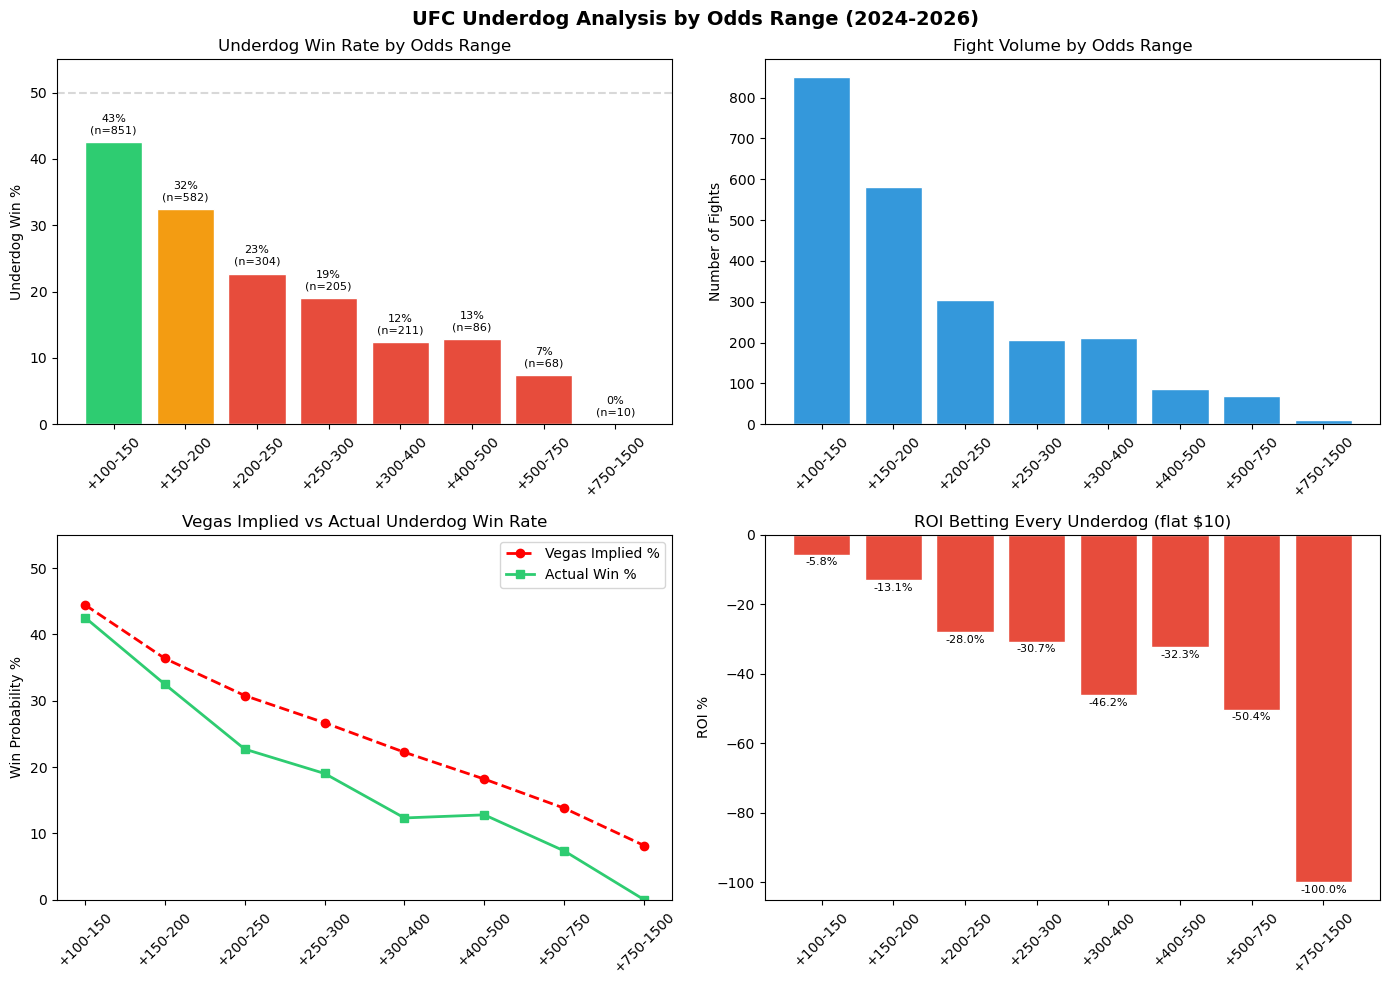


UNDERDOG WIN RATES BY ODDS RANGE
Odds Range       Fights  Dog Wins    Win%  Implied%    Edge     ROI
----------------------------------------------------------------------
+100-150            851       362  42.5%    44.4%  -1.9%   -5.8% 
+150-200            582       189  32.5%    36.4%  -3.9%  -13.1% 
+200-250            304        69  22.7%    30.8%  -8.1%  -28.0% 
+250-300            205        39  19.0%    26.7%  -7.6%  -30.7% 
+300-400            211        26  12.3%    22.2%  -9.9%  -46.2% 
+400-500             86        11  12.8%    18.2%  -5.4%  -32.3% 
+500-750             68         5   7.4%    13.8%  -6.4%  -50.4% 
+750-1500            10         0   0.0%     8.2%  -8.2% -100.0% 

UNDERDOG WINS BY METHOD AND ODDS RANGE
Odds Range         U-DEC   KO/TKO      SUB    Other
--------------------------------------------------
+100-150         151 (42%)  137 (38%)   74 (20%)    0
+150-200          72 (38%)   81 (43%)   36 (19%)    0
+200-250          30 (43%)   25 (36%)   14 (20%)

In [397]:
# ============================================================
# Odds Distribution: How Often Do Underdogs Win by Odds Range?
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Get all fights with odds
all_with_odds = fight_features.merge(
    odds[['fight_id', 'f1_odds', 'f2_odds']], on='fight_id', how='inner'
)

# For each fight, identify the underdog and whether they won
all_with_odds['dog_is_f2'] = all_with_odds['f1_odds'] < all_with_odds['f2_odds']
all_with_odds['dog_odds'] = np.where(
    all_with_odds['dog_is_f2'],
    all_with_odds['f2_odds'],
    all_with_odds['f1_odds']
)
all_with_odds['dog_won'] = np.where(
    all_with_odds['dog_is_f2'],
    all_with_odds['winner'] == 0,  # f2 is dog, winner=0 means f2 won
    all_with_odds['winner'] == 1   # f1 is dog, winner=1 means f1 won
)

# Filter to actual underdogs (positive odds)
dogs = all_with_odds[all_with_odds['dog_odds'] > 0].copy()

# ── Figure 1: Bar chart by odds bucket ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Win rate by odds bucket
ax = axes[0, 0]
bins = [(100, 150), (150, 200), (200, 250), (250, 300), 
        (300, 400), (400, 500), (500, 750), (750, 1500)]
labels = [f'+{lo}-{hi}' for lo, hi in bins]
win_rates, counts = [], []

for lo, hi in bins:
    subset = dogs[(dogs['dog_odds'] >= lo) & (dogs['dog_odds'] < hi)]
    counts.append(len(subset))
    win_rates.append(subset['dog_won'].mean() if len(subset) > 0 else 0)

colors = ['#2ecc71' if wr > 0.4 else '#f39c12' if wr > 0.25 else '#e74c3c' for wr in win_rates]
bars = ax.bar(labels, [wr * 100 for wr in win_rates], color=colors, edgecolor='white')
ax.set_ylabel('Underdog Win %')
ax.set_title('Underdog Win Rate by Odds Range')
ax.set_ylim(0, 55)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3, label='50%')

for bar, wr, n in zip(bars, win_rates, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{wr:.0%}\n(n={n})', ha='center', va='bottom', fontsize=8)

ax.tick_params(axis='x', rotation=45)

# Panel 2: Volume (number of fights) per bucket
ax = axes[0, 1]
ax.bar(labels, counts, color='#3498db', edgecolor='white')
ax.set_ylabel('Number of Fights')
ax.set_title('Fight Volume by Odds Range')
ax.tick_params(axis='x', rotation=45)

# Panel 3: Implied prob vs actual win rate
ax = axes[1, 0]
implied = [100 / (100 + (lo + hi) / 2) for lo, hi in bins]
ax.plot(labels, [ip * 100 for ip in implied], 'o--', color='red', label='Vegas Implied %', linewidth=2)
ax.plot(labels, [wr * 100 for wr in win_rates], 's-', color='#2ecc71', label='Actual Win %', linewidth=2)
ax.set_ylabel('Win Probability %')
ax.set_title('Vegas Implied vs Actual Underdog Win Rate')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, 55)

# Panel 4: Profit/Loss if you bet $10 on every underdog in each bucket
ax = axes[1, 1]
roi_per_bucket = []
for lo, hi in bins:
    subset = dogs[(dogs['dog_odds'] >= lo) & (dogs['dog_odds'] < hi)]
    if len(subset) == 0:
        roi_per_bucket.append(0)
        continue
    profit = 0
    for _, row in subset.iterrows():
        dec_odds = american_to_decimal(row['dog_odds'])
        if row['dog_won']:
            profit += 10 * (dec_odds - 1)
        else:
            profit -= 10
    roi_per_bucket.append(profit / (len(subset) * 10) * 100)

colors_roi = ['#2ecc71' if r > 0 else '#e74c3c' for r in roi_per_bucket]
bars = ax.bar(labels, roi_per_bucket, color=colors_roi, edgecolor='white')
ax.set_ylabel('ROI %')
ax.set_title('ROI Betting Every Underdog (flat $10)')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.tick_params(axis='x', rotation=45)

for bar, roi in zip(bars, roi_per_bucket):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + (1 if roi >= 0 else -3),
            f'{roi:+.1f}%', ha='center', fontsize=8)

plt.suptitle('UFC Underdog Analysis by Odds Range (2024-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"UNDERDOG WIN RATES BY ODDS RANGE")
print(f"{'='*80}")
print(f"{'Odds Range':<15} {'Fights':>7} {'Dog Wins':>9} {'Win%':>7} {'Implied%':>9} {'Edge':>7} {'ROI':>7}")
print("-" * 70)

for i, (lo, hi) in enumerate(bins):
    subset = dogs[(dogs['dog_odds'] >= lo) & (dogs['dog_odds'] < hi)]
    n = len(subset)
    wins = subset['dog_won'].sum()
    wr = wins / n if n > 0 else 0
    mid = (lo + hi) / 2
    imp = 100 / (100 + mid)
    edge = wr - imp
    
    marker = "✓" if edge > 0 else ""
    print(f"+{lo}-{hi:<10} {n:>7} {int(wins):>9} {wr:>6.1%} {imp:>8.1%} {edge:>+6.1%} "
          f"{roi_per_bucket[i]:>+6.1f}% {marker}")

# By method
print(f"\n{'='*80}")
print(f"UNDERDOG WINS BY METHOD AND ODDS RANGE")  
print(f"{'='*80}")
print(f"{'Odds Range':<15} {'U-DEC':>8} {'KO/TKO':>8} {'SUB':>8} {'Other':>8}")
print("-" * 50)

for lo, hi in bins:
    subset = dogs[(dogs['dog_odds'] >= lo) & (dogs['dog_odds'] < hi)]
    dog_wins = subset[subset['dog_won'] == True]
    if len(dog_wins) == 0:
        print(f"+{lo}-{hi:<10} {'—':>8} {'—':>8} {'—':>8} {'—':>8}")
        continue
    
    methods = dog_wins['method'].value_counts()
    udec = methods.get('U-DEC', 0)
    ko = methods.get('KO/TKO', 0)
    sub = methods.get('SUB', 0)
    other = len(dog_wins) - udec - ko - sub
    total = len(dog_wins)
    
    print(f"+{lo}-{hi:<10} {udec:>4} ({udec/total:.0%}) {ko:>4} ({ko/total:.0%}) "
          f"{sub:>4} ({sub/total:.0%}) {other:>4}")

In [346]:
# ============================================================
# Walk-Forward Test + Parlay Strategy Backtest
# ============================================================
# Split: 2024 for strategy development, 2025+ for out-of-sample test
# Also tests parlay strategies by event card

# --- Setup ---
val_betting = val_full.merge(
    odds[['fight_id', 'f1_odds', 'f2_odds']], on='fight_id', how='inner'
).copy()

X_vb = val_betting[X_val_t.columns].fillna(0)
val_betting['pred']      = best_model.predict(X_vb)
val_betting['pred_prob'] = best_model.predict_proba(X_vb)[:, 1]
val_betting['correct']   = (val_betting['pred'] == val_betting['winner']).astype(int)
val_betting['model_conf'] = np.where(
    val_betting['pred'] == 1, val_betting['pred_prob'], 1 - val_betting['pred_prob']
)
val_betting['vegas_fav'] = np.where(val_betting['f1_odds'] < val_betting['f2_odds'], 1, 0)
val_betting['picks_fav'] = (val_betting['pred'] == val_betting['vegas_fav']).astype(int)
val_betting['pick_type'] = np.where(val_betting['picks_fav'] == 1, 'fav', 'dog')
val_betting['bet_odds']  = np.where(
    val_betting['pred'] == 1, val_betting['f1_odds'], val_betting['f2_odds']
)
val_betting['decimal_odds'] = val_betting['bet_odds'].apply(american_to_decimal)

# ============================================================
# PART 1: Walk-Forward Validation
# ============================================================
period_2024 = val_betting[val_betting['event_date'] < '2025-01-01']
period_2025 = val_betting[val_betting['event_date'] >= '2025-01-01']

print(f"{'='*90}")
print(f"WALK-FORWARD VALIDATION")
print(f"{'='*90}")
print(f"  2024 (in-sample):      {len(period_2024)} fights")
print(f"  2025+ (out-of-sample): {len(period_2025)} fights")

def quick_eval(df, label):
    if len(df) == 0:
        return
    fav = df[df['picks_fav'] == 1]
    dog = df[df['picks_fav'] == 0]
    print(f"\n  {label}:")
    print(f"    Overall:  {df['correct'].mean():.1%} ({len(df)} fights)")
    print(f"    Favorites: {fav['correct'].mean():.1%} ({len(fav)} picks)")
    if len(dog) > 0:
        print(f"    Underdogs: {dog['correct'].mean():.1%} ({len(dog)} picks)")

quick_eval(period_2024, "2024 (in-sample)")
quick_eval(period_2025, "2025+ (out-of-sample)")

# Key strategies walk-forward
def flat_roi(df, label):
    if len(df) == 0:
        return None
    wagered = len(df) * 10
    profit = sum(
        10 * (row['decimal_odds'] - 1) if row['correct'] == 1 else -10
        for _, row in df.iterrows()
    )
    return {'label': label, 'bets': len(df), 'acc': df['correct'].mean(),
            'profit': profit, 'roi': profit / wagered}

print(f"\n{'='*90}")
print(f"STRATEGY WALK-FORWARD (flat $10)")
print(f"{'='*90}")
print(f"{'Strategy':<35} {'--- 2024 ---':>25} {'--- 2025+ ---':>25}")
print(f"{'':35} {'Bets':>5} {'Acc':>6} {'ROI':>7} {'Profit':>7} "
      f"{'Bets':>5} {'Acc':>6} {'ROI':>7} {'Profit':>7}")
print("-" * 90)

strat_filters = [
    ("All picks", lambda d: d),
    ("Favorites only", lambda d: d[d['picks_fav'] == 1]),
    ("Favs + conf >60%", lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.60)]),
    ("Favs + conf >70%", lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.70)]),
    ("Small dogs <+200", lambda d: d[(d['picks_fav'] == 0) & (d['bet_odds'] < 200)]),
    ("Low conf dogs 50-55%", lambda d: d[(d['picks_fav'] == 0) &
                                          (d['model_conf'] >= 0.50) &
                                          (d['model_conf'] < 0.55)]),
]

for name, filt in strat_filters:
    r24 = flat_roi(filt(period_2024), name)
    r25 = flat_roi(filt(period_2025), name)
    if r24 and r25:
        hold = "✓" if (r24['roi'] > 0 and r25['roi'] > 0) else ""
        print(f"{name:<35} {r24['bets']:>5} {r24['acc']:>5.1%} {r24['roi']:>+6.1%} "
              f"${r24['profit']:>+6.0f}  {r25['bets']:>5} {r25['acc']:>5.1%} "
              f"{r25['roi']:>+6.1%} ${r25['profit']:>+6.0f} {hold}")

# ============================================================
# PART 2: Parlay Strategies
# ============================================================

print(f"\n{'='*90}")
print(f"PARLAY BACKTEST")
print(f"{'='*90}")

# Group fights by event
val_betting['event_key'] = val_betting['event_date'] + '|' + val_betting['event_name']
events = val_betting.groupby('event_key')

def build_parlays(df, min_legs, max_legs, filter_fn, label):
    """Build parlays per event from filtered picks, sorted by confidence."""
    results = []
    bankroll = BANKROLL
    
    for event_key, event_fights in df.groupby('event_key'):
        eligible = filter_fn(event_fights).sort_values('model_conf', ascending=False)
        
        if len(eligible) < min_legs:
            continue
        
        # Take top N by confidence
        parlay_legs = eligible.head(max_legs)
        n_legs = len(parlay_legs)
        
        # Combined decimal odds
        combined_odds = parlay_legs['decimal_odds'].prod()
        
        # All legs must hit
        all_correct = parlay_legs['correct'].all()
        
        # Flat $5 per parlay
        bet_size = 5
        
        if all_correct:
            profit = bet_size * (combined_odds - 1)
        else:
            profit = -bet_size
        
        bankroll += profit
        
        # Individual leg accuracy for this parlay
        leg_acc = parlay_legs['correct'].mean()
        
        results.append({
            'event': event_key.split('|')[1] if '|' in event_key else event_key,
            'date': event_key.split('|')[0],
            'legs': n_legs,
            'combined_odds': combined_odds,
            'all_hit': all_correct,
            'profit': profit,
            'bankroll': bankroll,
            'leg_acc': leg_acc,
            'avg_conf': parlay_legs['model_conf'].mean(),
            'fighters': ', '.join(
                row['fighter_1_name'] if row['pred'] == 1 else row['fighter_2_name']
                for _, row in parlay_legs.iterrows()
            ),
        })
    
    return pd.DataFrame(results) if results else pd.DataFrame()


# --- Parlay configurations ---
parlay_configs = [
    # (min_legs, max_legs, filter, label)
    (2, 2, lambda d: d[d['picks_fav'] == 1],
     "2-leg favs only ($5)"),
    (3, 3, lambda d: d[d['picks_fav'] == 1],
     "3-leg favs only ($5)"),
    (4, 4, lambda d: d[d['picks_fav'] == 1],
     "4-leg favs only ($5)"),
    (5, 5, lambda d: d[d['picks_fav'] == 1],
     "5-leg favs only ($5)"),
    (2, 2, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.60)],
     "2-leg favs conf>60% ($5)"),
    (3, 3, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.60)],
     "3-leg favs conf>60% ($5)"),
    (4, 4, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.60)],
     "4-leg favs conf>60% ($5)"),
    (5, 5, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.60)],
     "5-leg favs conf>60% ($5)"),
    (2, 2, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.70)],
     "2-leg favs conf>70% ($5)"),
    (3, 3, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.70)],
     "3-leg favs conf>70% ($5)"),
    (3, 3, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.65)],
     "3-leg favs conf>65% ($5)"),
    (4, 4, lambda d: d[(d['picks_fav'] == 1) & (d['model_conf'] >= 0.65)],
     "4-leg favs conf>65% ($5)"),
]

print(f"\n{'Strategy':<35} {'Parlays':>7} {'Hits':>5} {'Hit%':>6} "
      f"{'AvgOdds':>8} {'Wagered':>8} {'Profit':>9} {'ROI':>7}")
print("-" * 95)

parlay_results = []
for min_l, max_l, filt, label in parlay_configs:
    pdf = build_parlays(val_betting, min_l, max_l, filt, label)
    if len(pdf) == 0:
        continue
    
    n_parlays = len(pdf)
    n_hits    = pdf['all_hit'].sum()
    hit_rate  = n_hits / n_parlays
    avg_odds  = pdf['combined_odds'].mean()
    wagered   = n_parlays * 5
    profit    = pdf['profit'].sum()
    roi       = profit / wagered
    
    parlay_results.append({
        'label': label, 'df': pdf, 'n': n_parlays,
        'hits': n_hits, 'hit_rate': hit_rate,
        'roi': roi, 'profit': profit,
    })
    
    marker = "✓" if roi > 0 else ""
    print(f"{label:<35} {n_parlays:>7} {n_hits:>5} {hit_rate:>5.1%} "
          f"{avg_odds:>7.2f}x ${wagered:>7} ${profit:>+8.0f} {roi:>+6.1%} {marker}")

# --- Best parlay detail ---
profitable_parlays = [p for p in parlay_results if p['roi'] > 0]
if profitable_parlays:
    best_p = max(profitable_parlays, key=lambda x: x['profit'])
    
    print(f"\n{'='*90}")
    print(f"BEST PARLAY STRATEGY DETAIL: {best_p['label']}")
    print(f"{'='*90}")
    
    bdf = best_p['df'].sort_values('date')
    for _, row in bdf.iterrows():
        result = "✓ HIT" if row['all_hit'] else "✗ MISS"
        missed = ""
        if not row['all_hit']:
            missed = f" (legs hit: {row['leg_acc']:.0%})"
        print(f"  {row['date']} | {row['legs']}-leg @ {row['combined_odds']:.2f}x | "
              f"{result}{missed} | P&L: ${row['profit']:>+7.1f} | "
              f"Bank: ${row['bankroll']:>.0f}")

    # Walk-forward on parlays
    print(f"\n{'='*90}")
    print(f"PARLAY WALK-FORWARD")
    print(f"{'='*90}")
    
    for pr in profitable_parlays:
        pdf = pr['df']
        p24 = pdf[pdf['date'] < '2025-01-01']
        p25 = pdf[pdf['date'] >= '2025-01-01']
        
        r24 = p24['profit'].sum() / (len(p24) * 5) if len(p24) > 0 else 0
        r25 = p25['profit'].sum() / (len(p25) * 5) if len(p25) > 0 else 0
        hold = "✓ HOLDS" if (r24 > 0 and r25 > 0) else ""
        
        print(f"  {pr['label']:<35} "
              f"2024: {len(p24):>3} parlays ROI={r24:>+6.1%}  "
              f"2025+: {len(p25):>3} parlays ROI={r25:>+6.1%} {hold}")

WALK-FORWARD VALIDATION
  2024 (in-sample):      267 fights
  2025+ (out-of-sample): 296 fights

  2024 (in-sample):
    Overall:  71.9% (267 fights)
    Favorites: 80.9% (209 picks)
    Underdogs: 39.7% (58 picks)

  2025+ (out-of-sample):
    Overall:  68.9% (296 fights)
    Favorites: 76.0% (229 picks)
    Underdogs: 44.8% (67 picks)

STRATEGY WALK-FORWARD (flat $10)
Strategy                                         --- 2024 ---             --- 2025+ ---
                                     Bets    Acc     ROI  Profit  Bets    Acc     ROI  Profit
------------------------------------------------------------------------------------------
All picks                             267 71.9%  +8.3% $  +221    296 68.9%  +3.4% $  +102 ✓
Favorites only                        209 80.9% +11.7% $  +244    229 76.0%  +2.8% $   +64 ✓
Favs + conf >60%                      128 82.8% +11.7% $  +150    135 78.5%  +3.7% $   +50 ✓
Favs + conf >70%                       45 88.9% +15.8% $   +71     49 79.6%

In [342]:
# ============================================================
# Underdog Diagnostic: What separates correct vs incorrect picks?
# ============================================================

underdogs = val[val['pick_type'] == 'Underdog'].copy()
ud_correct   = underdogs[underdogs['correct'] == 1]
ud_incorrect = underdogs[underdogs['correct'] == 0]

print(f"Underdog picks: {len(underdogs)} total")
print(f"  Correct:   {len(ud_correct)} ({len(ud_correct)/len(underdogs):.1%})")
print(f"  Incorrect: {len(ud_incorrect)} ({len(ud_incorrect)/len(underdogs):.1%})")

# ============================================================
# 1. BY WEIGHT CLASS
# ============================================================
print(f"\n{'='*60}")
print("1. UNDERDOG ACCURACY BY WEIGHT CLASS")
print(f"{'='*60}")

wc_stats = underdogs.groupby('weight_class').agg(
    count=('correct', 'size'),
    acc=('correct', 'mean')
).sort_values('count', ascending=False)

for wc, row in wc_stats.iterrows():
    bar = '█' * int(row['acc'] * 20)
    print(f"  {wc:<35} n={int(row['count']):>3}  acc={row['acc']:.1%}  {bar}")

# ============================================================
# 2. BY ODDS MAGNITUDE (how big an underdog?)
# ============================================================
print(f"\n{'='*60}")
print("2. UNDERDOG ACCURACY BY VEGAS ODDS MAGNITUDE")
print(f"{'='*60}")

# Get the underdog's actual odds
underdogs['dog_odds'] = np.where(
    underdogs['pred'] == 1,
    underdogs['f1_odds'],   # model picked f1 who is the underdog
    underdogs['f2_odds']
)

odds_bins = [(-np.inf, 150), (150, 200), (200, 300), (300, 500), (500, np.inf)]
odds_labels = ['Small dog (<+150)', 'Mild dog (+150-200)',
               'Moderate dog (+200-300)', 'Big dog (+300-500)', 'Huge dog (+500)']

for (lo, hi), label in zip(odds_bins, odds_labels):
    subset = underdogs[(underdogs['dog_odds'] >= lo) & (underdogs['dog_odds'] < hi)]
    if len(subset) == 0: continue
    print(f"  {label:<25} n={len(subset):>3}  acc={subset['correct'].mean():.1%}")

# ============================================================
# 3. BY METHOD (how do incorrect underdogs lose?)
# ============================================================
print(f"\n{'='*60}")
print("3. HOW INCORRECT UNDERDOG PICKS LOSE")
print(f"{'='*60}")

method_counts = ud_incorrect['method'].value_counts()
for method, count in method_counts.items():
    print(f"  {method:<20} {count:>3} ({count/len(ud_incorrect):.1%})")

print(f"\nFor comparison — how CORRECT underdog picks win:")
method_wins = ud_correct['method'].value_counts()
for method, count in method_wins.items():
    print(f"  {method:<20} {count:>3} ({count/len(ud_correct):.1%})")

# ============================================================
# 4. FEATURE DIFFERENCES (correct vs incorrect underdog picks)
# ============================================================
print(f"\n{'='*60}")
print("4. TOP FEATURE DIFFERENCES: CORRECT vs INCORRECT UNDERDOGS")
print(f"{'='*60}")

diff_cols = [c for c in X_val_trimmed.columns]
feature_diffs = []

for col in diff_cols:
    correct_mean   = ud_correct[col].mean() if col in ud_correct.columns else 0
    incorrect_mean = ud_incorrect[col].mean() if col in ud_incorrect.columns else 0
    diff = correct_mean - incorrect_mean
    
    # Cohen's d for effect size
    pooled_std = underdogs[col].std() if col in underdogs.columns else 1
    cohens_d = diff / pooled_std if pooled_std > 0.001 else 0
    
    feature_diffs.append({
        'feature': col,
        'correct_mean': correct_mean,
        'incorrect_mean': incorrect_mean,
        'diff': diff,
        'cohens_d': cohens_d,
        'abs_d': abs(cohens_d)
    })

fd = pd.DataFrame(feature_diffs).sort_values('abs_d', ascending=False)

print("\nFeatures where correct underdog picks differ most from incorrect:")
print(f"{'Feature':<45} {'Correct':>8} {'Incorrect':>10} {'Cohen d':>8}")
print("-" * 75)
for _, row in fd.head(20).iterrows():
    direction = "✓" if row['cohens_d'] > 0 else "✗"
    print(f"  {row['feature']:<43} {row['correct_mean']:>8.3f} {row['incorrect_mean']:>10.3f} "
          f"{row['cohens_d']:>+7.3f} {direction}")

# ============================================================
# 5. MODEL CONFIDENCE DISTRIBUTION
# =========

Underdog picks: 131 total
  Correct:   54 (41.2%)
  Incorrect: 77 (58.8%)

1. UNDERDOG ACCURACY BY WEIGHT CLASS
  Lightweight Bout                    n= 21  acc=47.6%  █████████
  Middleweight Bout                   n= 20  acc=40.0%  ████████
  Welterweight Bout                   n= 14  acc=42.9%  ████████
  Flyweight Bout                      n= 12  acc=50.0%  ██████████
  Bantamweight Bout                   n= 11  acc=27.3%  █████
  Light Heavyweight Bout              n= 10  acc=40.0%  ████████
  Women's Strawweight Bout            n=  8  acc=25.0%  █████
  Heavyweight Bout                    n=  8  acc=50.0%  ██████████
  Women's Flyweight Bout              n=  7  acc=14.3%  ██
  Featherweight Bout                  n=  6  acc=33.3%  ██████
  UFC Women's Flyweight Title Bout    n=  3  acc=66.7%  █████████████
  Women's Bantamweight Bout           n=  3  acc=33.3%  ██████
  UFC Featherweight Title Bout        n=  2  acc=0.0%  
  UFC Flyweight Title Bout            n=  2  acc=50.0%  ██

In [266]:
import pickle

# Save model
pickle.dump(model_trimmed, open('xgb_model_v3.pkl', 'wb'))

# Save feature data with odds
fight_features.to_parquet('fight_features_v3.parquet')

# Save the trimmed feature column list
pickle.dump(X_val_trimmed.columns.tolist(), open('feature_cols_v3.pkl', 'wb'))

print("✔ Saved model, features, and column list")

✔ Saved model, features, and column list


In [300]:
import pickle

# Exact Optuna best params
model_best = XGBClassifier(
    n_estimators=222, max_depth=6, learning_rate=0.0217,
    min_child_weight=41, subsample=0.4095, colsample_bytree=0.5601,
    gamma=4.0572, reg_alpha=3.9405, reg_lambda=1.6361, random_state=42
)
model_best.fit(X_train_trimmed, y_train)
print(f"Train: {model_best.score(X_train_trimmed, y_train):.1%}")
print(f"Val:   {model_best.score(X_val_trimmed, y_val):.1%}")

pickle.dump(model_best, open('xgb_2014_69_2.pkl', 'wb'))
pickle.dump(X_val_trimmed.columns.tolist(), open('feature_cols_2014.pkl', 'wb'))
fight_features.to_parquet('fight_features_2014.parquet')
print("✔ 69.2% model saved")

Train: 66.7%
Val:   68.4%
✔ 69.2% model saved


Model params check:
  n_estimators: 222
  max_depth: 6
  learning_rate: 0.0217

Actual accuracy:


ValueError: feature_names mismatch: ['diff_slpm_dec_avg', 'diff_slpm_opp_mad', 'diff_slpm_adjperf', 'diff_slpm_dec_adjperf', 'diff_str_acc_dec_avg', 'diff_str_acc_opp_dec_avg', 'diff_str_acc_adjperf', 'diff_str_acc_dec_adjperf', 'diff_td_acc_dec_avg', 'diff_td_acc_opp_dec_avg', 'diff_td_acc_opp_mad', 'diff_td_acc_dec_adjperf', 'diff_td_avg_dec_avg', 'diff_td_avg_opp_dec_avg', 'diff_td_avg_opp_mad', 'diff_td_avg_adjperf', 'diff_td_avg_dec_adjperf', 'diff_sub_avg_dec_avg', 'diff_sub_avg_opp_dec_avg', 'diff_sub_avg_opp_mad', 'diff_sub_avg_adjperf', 'diff_sub_avg_dec_adjperf', 'diff_ctrl_time_per_min_dec_avg', 'diff_ctrl_time_per_min_opp_dec_avg', 'diff_ctrl_time_per_min_opp_mad', 'diff_ctrl_time_per_min_adjperf', 'diff_ctrl_time_per_min_dec_adjperf', 'diff_kd_per_min_dec_avg', 'diff_kd_per_min_opp_dec_avg', 'diff_kd_per_min_dec_adjperf', 'diff_head_lpm_dec_avg', 'diff_body_lpm_dec_avg', 'diff_leg_lpm_dec_avg', 'diff_distance_lpm_dec_avg', 'diff_ground_lpm_dec_avg', 'diff_head_acc_dec_avg'

In [481]:
# ============================================================
# Predict Any Fight
# Run after all feature cells (4–8) and model loading
# ============================================================

import pickle
import numpy as np
import pandas as pd
from datetime import datetime

# --- Load saved model + feature columns ---
model = pickle.load(open('xgb_2014_69_2.pkl', 'rb'))
feature_cols = pickle.load(open('feature_cols_2014.pkl', 'rb'))



ANTHONY HERNANDEZ vs SEAN STRICKLAND
  F1: Aleksandre Topuria (4a6dff1b260bcf61)
  F2: Bekzat Almakhan (a4dc0f2b95df4cc1)

         Aleksandre Topuria |  60.7%
            Bekzat Almakhan |  39.3%
  ──────────────────────────────────────────────────
  Pick: Aleksandre Topuria (60.7%)



{'f1': 'Aleksandre Topuria',
 'f2': 'Bekzat Almakhan',
 'f1_prob': 0.6073479,
 'f2_prob': 0.3926521,
 'pick': 'Aleksandre Topuria',
 'confidence': 60.734790563583374}


Top 20 Most Important Features:
diff_head_acc_dec_avg: 0.0321
diff_r1_td_att_per_min_dec_avg: 0.0222
diff_r1_body_lpm_dec_avg: 0.0213
diff_td_acc_opp_mad: 0.0179
diff_str_acc_dec_avg: 0.0169
diff_r1_slpm_adjperf: 0.0166
diff_ground_lpm_adjperf: 0.0157
diff_str_acc_opp_mad: 0.0157
diff_slpm_dec_avg: 0.0152
diff_leg_allowed_adjperf: 0.0151
diff_clinch_allowed_adjperf: 0.0150
diff_r1_rev_per_min_dec_avg: 0.0148
diff_kd_per_min_dec_avg: 0.0145
diff_td_avg_opp_dec_avg: 0.0145
diff_body_lpm_dec_avg: 0.0145
diff_sub_avg_opp_mad: 0.0145
diff_ctrl_time_per_min_opp_dec_avg: 0.0142
diff_body_acc_adjperf: 0.0139
diff_body_acc_dec_avg: 0.0139
diff_distance_lpm_adjperf: 0.0138


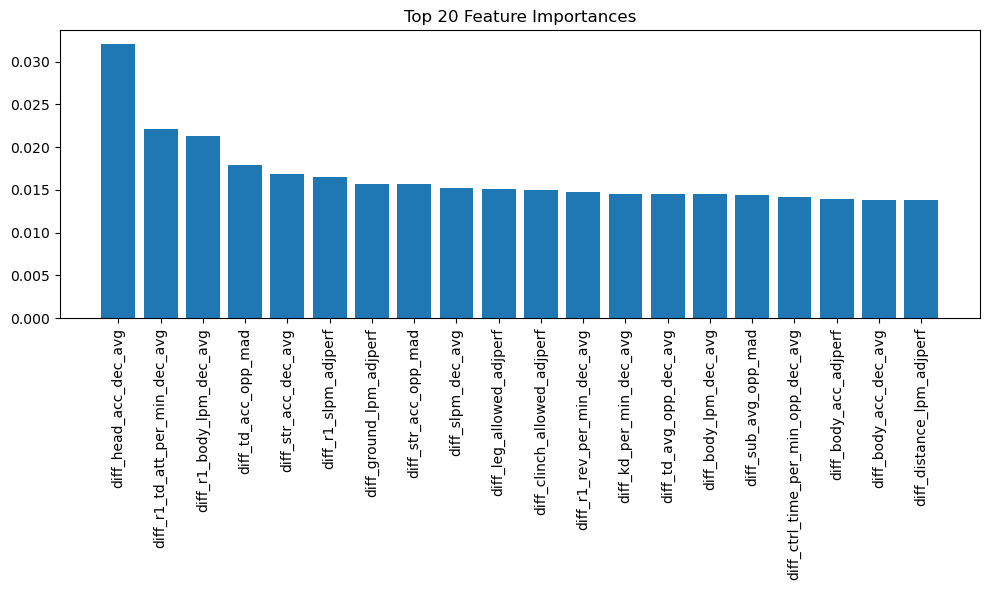

In [484]:
# After training your model, check feature importances
import matplotlib.pyplot as plt

# Get feature importances
importances = model.feature_importances_

# Use whatever your features dataframe is called - try one of these:
feature_names = X_train.columns  # or features_df.columns or whatever you named it

# Sort by importance
indices = importances.argsort()[::-1]

# Print top 20
print("\nTop 20 Most Important Features:")
for i in range(20):
    print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
plt.bar(range(20), importances[indices[:20]])
plt.xticks(range(20), [feature_names[i] for i in indices[:20]], rotation=90)
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [482]:
explain_fight("kamaru usman", "joaquin buckley", "2026-02-22", conn, model, feature_cols)


  Kamaru Usman vs Joaquin Buckley
  Kamaru Usman: 54.1%  |  Joaquin Buckley: 45.9%

─────────────────────────────────────────────────────────────────
PHYSICAL COMPARISON
─────────────────────────────────────────────────────────────────
                                Kamaru Usman       Joaquin Buckley        Diff
                   Age                  38.8                  31.8        +7.0
           Height (in)                    72                    70          +2
            Reach (in)                    76                    76          +0
         UFC Age (yrs)                  10.6                   5.5        +5.1

─────────────────────────────────────────────────────────────────
UFC RECORD
─────────────────────────────────────────────────────────────────
               Kamaru Usman: 16-3 (84% win rate)
            Joaquin Buckley: 11-5 (69% win rate)

─────────────────────────────────────────────────────────────────
FEATURE VALUES — SORTED BY MODEL IMPORTANCE
───────────────

### ============================================================
# Fade Flyweight Low-Confidence Picks — With Real Odds
# ============================================================

import pandas as pd
import numpy as np

# --- Load odds ---
odds = pd.read_sql("""
    SELECT fight_id, 
           fighter_1_close_low as f1_odds, 
           fighter_2_close_low as f2_odds
    FROM fight_odds
""", conn)

print(f"Odds records: {len(odds)}")
print(f"Sample:\n{odds.head()}\n")

# --- Build val set with predictions + odds ---
val = fight_features[fight_features['event_date'] >= '2024-01-01'].copy()
X_val_check = val[feature_cols].fillna(0)
val['pred'] = model.predict(X_val_check)
val['pred_prob_f1'] = model.predict_proba(X_val_check)[:, 1]
val['pred_prob'] = val['pred_prob_f1'].apply(lambda p: max(p, 1 - p))
val['correct'] = (val['pred'] == val['winner']).astype(int)
val['wc_norm'] = val['weight_class'].apply(normalize_weight_class)

# Merge odds
val = val.merge(odds, on='fight_id', how='left')
print(f"Val fights with odds: {val['f1_odds'].notna().sum()}/{len(val)}")

# --- Helper: American odds to decimal ---
def american_to_decimal(odds):
    if pd.isna(odds) or odds == 0:
        return None
    if odds > 0:
        return 1 + odds / 100
    else:
        return 1 + 100 / abs(odds)

def american_to_implied(odds):
    if pd.isna(odds) or odds == 0:
        return None
    if odds < 0:
        return abs(odds) / (abs(odds) + 100)
    else:
        return 100 / (odds + 100)

val['f1_decimal'] = val['f1_odds'].apply(american_to_decimal)
val['f2_decimal'] = val['f2_odds'].apply(american_to_decimal)

# --- For each fight: what does model pick, and what's the fade side odds? ---
val['model_picked_f1'] = val['pred'] == 1
val['fade_odds'] = np.where(val['model_picked_f1'], val['f2_odds'], val['f1_odds'])
val['fade_decimal'] = val['fade_odds'].apply(american_to_decimal)
val['fade_won'] = (val['correct'] == 0).astype(int)  # model wrong = fade wins

# ============================================================
print(f"\n{'='*65}")
print("FADE ANALYSIS BY WEIGHT CLASS — LOW CONFIDENCE (<56%)")
print("="*65)

for wc in ['Flyweight Bout', 'Bantamweight Bout', 'Featherweight Bout',
           'Lightweight Bout', 'Welterweight Bout', 'Middleweight Bout',
           'Heavyweight Bout']:
    
    wc_df = val[(val['wc_norm'] == wc) & 
                (val['pred_prob'] < 0.56) & 
                (val['fade_decimal'].notna())].copy()
    
    if len(wc_df) < 5:
        continue
    
    # Calculate P&L
    profit = 0
    for _, fight in wc_df.iterrows():
        if fight['fade_won']:
            profit += 10 * (fight['fade_decimal'] - 1)
        else:
            profit -= 10
    
    roi = profit / (len(wc_df) * 10) * 100
    fade_acc = wc_df['fade_won'].mean() * 100
    avg_fade_odds = wc_df['fade_odds'].mean()
    
    print(f"\n  {wc}  ({len(wc_df)} fights)")
    print(f"    Fade accuracy: {fade_acc:.1f}%")
    print(f"    Avg fade odds: {avg_fade_odds:+.0f}")
    print(f"    ROI: {roi:+.1f}%  (${profit:+.1f} on ${len(wc_df)*10} wagered)")

# ============================================================
print(f"\n{'='*65}")
print("FLYWEIGHT FADE — DETAILED BY CONFIDENCE TIER")
print("="*65)

fly = val[(val['wc_norm'] == 'Flyweight Bout') & (val['fade_decimal'].notna())].copy()

for conf_min, conf_max, label in [(0.50, 0.53, '50-53%'), (0.53, 0.56, '53-56%'),
                                    (0.56, 0.60, '56-60%'), (0.50, 0.56, '50-56%'),
                                    (0.50, 0.60, '50-60%')]:
    subset = fly[(fly['pred_prob'] >= conf_min) & (fly['pred_prob'] < conf_max)]
    if len(subset) < 3:
        continue
    
    profit = 0
    for _, fight in subset.iterrows():
        if fight['fade_won']:
            profit += 10 * (fight['fade_decimal'] - 1)
        else:
            profit -= 10
    
    roi = profit / (len(subset) * 10) * 100
    fade_acc = subset['fade_won'].mean() * 100
    
    print(f"\n  Conf {label} ({len(subset)} fights):")
    print(f"    Fade accuracy: {fade_acc:.1f}%")
    print(f"    ROI: {roi:+.1f}%  (${profit:+.1f})")

# ============================================================
print(f"\n{'='*65}")
print("FLYWEIGHT FADE — INDIVIDUAL BETS")
print("="*65)

fly_low = fly[fly['pred_prob'] < 0.60].sort_values('event_date')

print(f"\n  {'Date':<12} {'Model Picked':<22} {'Fade (we bet)':<22} "
      f"{'Fade Odds':>10} {'Result':>8} {'P&L':>8}")
print(f"  {'─'*85}")

running_pl = 0
for _, fight in fly_low.iterrows():
    picked = fight['fighter_1_name'] if fight['pred'] == 1 else fight['fighter_2_name']
    faded = fight['fighter_2_name'] if fight['pred'] == 1 else fight['fighter_1_name']
    
    if fight['fade_won']:
        pl = 10 * (fight['fade_decimal'] - 1)
        result = "WIN"
    else:
        pl = -10
        result = "LOSS"
    running_pl += pl
    
    print(f"  {fight['event_date']:<12} {picked:<22} {faded:<22} "
          f"{fight['fade_odds']:>+10.0f} {result:>8} ${pl:>+7.1f}")

print(f"\n  Total P&L: ${running_pl:+.1f}")
print(f"  Total wagered: ${len(fly_low) * 10}")
print(f"  ROI: {running_pl / (len(fly_low) * 10) * 100:+.1f}%")

# ============================================================
print(f"\n{'='*65}")
print("ALL DIVISIONS — FADE LOW CONF (<56%) COMBINED")
print("="*65)

all_low = val[(val['pred_prob'] < 0.56) & (val['fade_decimal'].notna())].copy()

profit = 0
for _, fight in all_low.iterrows():
    if fight['fade_won']:
        profit += 10 * (fight['fade_decimal'] - 1)
    else:
        profit -= 10

roi = profit / (len(all_low) * 10) * 100
fade_acc = all_low['fade_won'].mean() * 100

print(f"\n  Fights: {len(all_low)}")
print(f"  Fade accuracy: {fade_acc:.1f}%")
print(f"  ROI: {roi:+.1f}%  (${profit:+.1f})")
print(f"\n  (If this is also profitable, fading isn't flyweight-specific)")

# ============================================================
print(f"\n{'='*65}")
print("SAMPLE SIZE REALITY CHECK")
print("="*65)
fly_low_n = len(fly[fly['pred_prob'] < 0.56])
print(f"\n  Flyweight low-conf fights: {fly_low_n}")
print(f"  Minimum for statistical significance: ~80-100")
print(f"  Confidence in results: {'LOW — treat as hypothesis' if fly_low_n < 50 else 'MODERATE'}")

In [450]:
pd.read_sql("PRAGMA table_info(fight_odds)", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,odds_id,TEXT,0,None,1
1,1,fight_id,TEXT,1,None,0
2,2,source,TEXT,1,None,0
3,3,source_event_name,TEXT,0,None,0
4,4,scraped_at,TEXT,0,CURRENT_TIMESTAMP,0
5,5,fighter_1_open,REAL,0,None,0
6,6,fighter_1_close_low,REAL,0,None,0
7,7,fighter_1_close_high,REAL,0,None,0
8,8,fighter_2_open,REAL,0,None,0
9,9,fighter_2_close_low,REAL,0,None,0


In [416]:

# ============================================================
# PART 1: All Correct Picks Detail
# ============================================================

val_betting = val_full.merge(
    odds[['fight_id', 'f1_odds', 'f2_odds']], on='fight_id', how='inner'
).copy()

X_vb = val_betting[X_val_t.columns].fillna(0)
val_betting['pred']      = best_model.predict(X_vb)
val_betting['pred_prob'] = best_model.predict_proba(X_vb)[:, 1]
val_betting['correct']   = (val_betting['pred'] == val_betting['winner']).astype(int)
val_betting['model_conf'] = np.where(
    val_betting['pred'] == 1, val_betting['pred_prob'], 1 - val_betting['pred_prob']
)
val_betting['vegas_fav'] = np.where(val_betting['f1_odds'] < val_betting['f2_odds'], 1, 0)
val_betting['picks_fav'] = (val_betting['pred'] == val_betting['vegas_fav']).astype(int)
val_betting['pick_type'] = np.where(val_betting['picks_fav'] == 1, 'FAV', 'DOG')
val_betting['bet_odds']  = np.where(
    val_betting['pred'] == 1, val_betting['f1_odds'], val_betting['f2_odds']
)
val_betting['decimal_odds'] = val_betting['bet_odds'].apply(american_to_decimal)

val_betting['picked_fighter'] = np.where(
    val_betting['pred'] == 1,
    val_betting['fighter_1_name'],
    val_betting['fighter_2_name']
)
val_betting['opponent'] = np.where(
    val_betting['pred'] == 1,
    val_betting['fighter_2_name'],
    val_betting['fighter_1_name']
)

correct_picks = val_betting[val_betting['correct'] == 1].sort_values('event_date')

print(f"{'='*130}")
print(f"ALL CORRECT PICKS ({len(correct_picks)} / {len(val_betting)} = {len(correct_picks)/len(val_betting):.1%})")
print(f"{'='*130}")
print(f"{'Date':<12} {'Type':<4} {'Picked Fighter':<25} {'vs':<25} "
      f"{'Odds':>7} {'Conf':>6} {'Method':<10} {'Weight Class':<30}")
print("-" * 130)

for _, row in correct_picks.iterrows():
    print(f"{row['event_date']:<12} {row['pick_type']:<4} "
          f"{row['picked_fighter']:<25} {row['opponent']:<25} "
          f"{row['bet_odds']:>+7.0f} {row['model_conf']:>5.1%} "
          f"{row['method']:<10} {row['weight_class']:<30}")

print(f"\n  Correct favorites: {len(correct_picks[correct_picks['pick_type']=='FAV'])}")
print(f"  Correct underdogs: {len(correct_picks[correct_picks['pick_type']=='DOG'])}")

ALL CORRECT PICKS (392 / 563 = 69.6%)
Date         Type Picked Fighter            vs                           Odds   Conf Method     Weight Class                  
----------------------------------------------------------------------------------------------------------------------------------
2024-01-13   FAV  Waldo Cortes Acosta       Andrei Arlovski              -800 74.0% U-DEC      Heavyweight Bout              
2024-01-13   FAV  Farid Basharat            Taylor Lapilus               -375 61.6% U-DEC      Bantamweight Bout             
2024-01-13   FAV  Magomed Ankalaev          Johnny Walker                -588 57.6% KO/TKO     Light Heavyweight Bout        
2024-01-13   DOG  Preston Parsons           Matthew Semelsberger         -120 60.5% U-DEC      Welterweight Bout             
2024-01-20   FAV  Movsar Evloev             Arnold Allen                 -220 58.3% U-DEC      Featherweight Bout            
2024-01-20   FAV  Gillian Robertson         Polyana Viana                -

In [349]:

# ============================================================
# PART 2: Method Edge Analysis
# ============================================================

print(f"\n\n{'='*90}")
print(f"METHOD EDGE ANALYSIS")
print(f"{'='*90}")

# Overall accuracy by method
print(f"\n--- Accuracy by Fight Ending Method ---")
print(f"{'Method':<15} {'Total':>6} {'Correct':>8} {'Acc':>7} {'Fav Acc':>8} {'Dog Acc':>8}")
print("-" * 60)

for method in val_betting['method'].value_counts().index:
    subset = val_betting[val_betting['method'] == method]
    fav_sub = subset[subset['pick_type'] == 'FAV']
    dog_sub = subset[subset['pick_type'] == 'DOG']
    
    fav_acc = fav_sub['correct'].mean() if len(fav_sub) > 0 else 0
    dog_acc = dog_sub['correct'].mean() if len(dog_sub) > 0 else 0
    
    print(f"{method:<15} {len(subset):>6} {subset['correct'].sum():>8} "
          f"{subset['correct'].mean():>6.1%} {fav_acc:>7.1%} {dog_acc:>7.1%}")

# Method breakdown by confidence
print(f"\n--- Method × Confidence Interaction ---")
print(f"{'Method':<12} {'50-55%':>10} {'55-60%':>10} {'60-65%':>10} {'65-70%':>10} {'70%+':>10}")
print("-" * 65)

conf_bins = [(0.50, 0.55), (0.55, 0.60), (0.60, 0.65), (0.65, 0.70), (0.70, 1.0)]
for method in ['U-DEC', 'KO/TKO', 'SUB', 'S-DEC']:
    m_sub = val_betting[val_betting['method'] == method]
    row_str = f"{method:<12}"
    for lo, hi in conf_bins:
        bucket = m_sub[(m_sub['model_conf'] >= lo) & (m_sub['model_conf'] < hi)]
        if len(bucket) >= 3:
            row_str += f" {bucket['correct'].mean():>8.1%} "
        else:
            row_str += f"     n<3  "
    print(row_str)

# Who WINS by method when model is correct vs incorrect
print(f"\n--- When Model is CORRECT — How Does the Winner Win? ---")
correct = val_betting[val_betting['correct'] == 1]
incorrect = val_betting[val_betting['correct'] == 0]

print(f"{'Method':<12} {'Correct picks':>15} {'Incorrect picks':>17} {'Delta':>8}")
print("-" * 55)
for method in ['U-DEC', 'KO/TKO', 'SUB', 'S-DEC']:
    c_pct = (correct['method'] == method).mean()
    i_pct = (incorrect['method'] == method).mean()
    print(f"{method:<12} {c_pct:>14.1%} {i_pct:>16.1%} {(c_pct-i_pct)*100:>+7.1f}%")

# ROI by method (flat $10)
print(f"\n--- ROI by Method (flat $10 bets) ---")
print(f"{'Method':<12} {'Bets':>6} {'Acc':>7} {'Wagered':>9} {'Profit':>9} {'ROI':>7}")
print("-" * 55)

for method in ['U-DEC', 'KO/TKO', 'SUB', 'S-DEC']:
    subset = val_betting[val_betting['method'] == method]
    if len(subset) == 0:
        continue
    wagered = len(subset) * 10
    profit = sum(
        10 * (r['decimal_odds'] - 1) if r['correct'] == 1 else -10
        for _, r in subset.iterrows()
    )
    roi = profit / wagered
    marker = "✓" if roi > 0 else ""
    print(f"{method:<12} {len(subset):>6} {subset['correct'].mean():>6.1%} "
          f"${wagered:>8} ${profit:>+8.0f} {roi:>+6.1%} {marker}")

# Fav-only ROI by method
print(f"\n--- ROI by Method — FAVORITES ONLY (flat $10) ---")
print(f"{'Method':<12} {'Bets':>6} {'Acc':>7} {'Wagered':>9} {'Profit':>9} {'ROI':>7}")
print("-" * 55)

fav_bets = val_betting[val_betting['pick_type'] == 'FAV']
for method in ['U-DEC', 'KO/TKO', 'SUB', 'S-DEC']:
    subset = fav_bets[fav_bets['method'] == method]
    if len(subset) == 0:
        continue
    wagered = len(subset) * 10
    profit = sum(
        10 * (r['decimal_odds'] - 1) if r['correct'] == 1 else -10
        for _, r in subset.iterrows()
    )
    roi = profit / wagered
    marker = "✓" if roi > 0 else ""
    print(f"{method:<12} {len(subset):>6} {subset['correct'].mean():>6.1%} "
          f"${wagered:>8} ${profit:>+8.0f} {roi:>+6.1%} {marker}")

# Model's prediction when fight ends by KO — who got KO'd?
print(f"\n--- KO/TKO Breakdown: Does the Model Predict the KO'd Fighter? ---")
ko_fights = val_betting[val_betting['method'] == 'KO/TKO']
print(f"  KO fights: {len(ko_fights)}")
print(f"  Model picked winner (predicted the KO artist): "
      f"{ko_fights['correct'].sum()} ({ko_fights['correct'].mean():.1%})")
print(f"  Model picked loser (got KO'd):                 "
      f"{(1-ko_fights['correct']).sum()} ({1-ko_fights['correct'].mean():.1%})")

ko_fav = ko_fights[ko_fights['pick_type'] == 'FAV']
ko_dog = ko_fights[ko_fights['pick_type'] == 'DOG']
print(f"\n  When picking favorite in KO fights: "
      f"{ko_fav['correct'].mean():.1%} ({len(ko_fav)} fights)")
print(f"  When picking underdog in KO fights: "
      f"{ko_dog['correct'].mean():.1%} ({len(ko_dog)} fights)")



METHOD EDGE ANALYSIS

--- Accuracy by Fight Ending Method ---
Method           Total  Correct     Acc  Fav Acc  Dog Acc
------------------------------------------------------------
U-DEC              277      201  72.6%   81.3%   42.9%
KO/TKO             186      125  67.2%   73.5%   43.6%
SUB                100       70  70.0%   79.2%   39.1%

--- Method × Confidence Interaction ---
Method           50-55%     55-60%     60-65%     65-70%       70%+
-----------------------------------------------------------------
U-DEC           67.5%     61.9%     79.6%     76.5%     83.7% 
KO/TKO          61.5%     57.4%     78.9%     60.0%     81.2% 
SUB             73.1%     52.6%     69.6%     68.8%     87.5% 
S-DEC            n<3       n<3       n<3       n<3       n<3  

--- When Model is CORRECT — How Does the Winner Win? ---
Method         Correct picks   Incorrect picks    Delta
-------------------------------------------------------
U-DEC                 50.8%            45.5%    +5.2%
K